# Data Pipeline — Rewritten Notebook (v3)

This notebook implements the complete data-processing pipeline for
*Endogenous Education Choice in Segmented Search Markets*.

**Changes from the original notebook (implementing the v3 action plan):**

| # | Change | Section |
|---|--------|---------|
| 1 | Vectorised `ym`-based window assignment (no Dict loop) | Helpers |
| 2 | Rename `winsorize_bounds` → `trim_bounds` | Helpers |
| 3 | Fix SCHLCOLL codes: `(3, 4)` not `(4, 5)` | Helpers |
| 4 | CLASSWKR kept as `(22, 25, 27, 28)` — verified | Helpers |
| 5 | COVID BLS correction using WHYABSNT | Helpers + Stage 1 |
| 6 | Corrected IND-to-JOLTS mapping (verified against 2024 ACS codes) | Helpers |
| 7 | Weighted industry skill shares (WTFINL) | Stage 1 |
| 8 | JOLTS units × 1000, download guard, missing-series error | Stage 3 |
| 9 | Default skill share = economy-wide average (not 0.5) | Stage 3 |
| 10 | J2J EE rate from Census J2J CSV (new Stage 5) | Stage 5 |
| 11 | Demographic turnover ν from matched CPS panels (new Stage 6) | Stage 6 |
| 12 | φ calibration from NSC data (new) | Stage 7 |
| 13 | Influence functions and Σ̂ computation (new Stage 8) | Stage 8 |
| 14 | 24 moments (θ_S/θ_U ratio removed) | Stage 7 |
| 15 | Comprehensive validation diagnostics (new Stage 9) | Stage 9 |


## Setup

Load all required packages.

In [1]:
using DataFrames
using CSV
using Arrow
using Statistics
using Printf
using HTTP, JSON3
using XLSX          # for reading NSC Excel file
using LinearAlgebra # for influence function / Σ computation

### Paths

Adjust `PROJECT_ROOT` if your notebook lives somewhere other than `code/notebooks/`.

In [2]:
# ── Paths ──────────────────────────────────────────────────────
const PROJECT_ROOT      = joinpath(@__DIR__, "..", "..")
const DATA_DIR          = joinpath(PROJECT_ROOT, "data")
const RAW_DIR           = joinpath(DATA_DIR, "raw")
const DERIVED_DIR       = joinpath(DATA_DIR, "derived")

const RAW_CPS_BASIC_DIR = joinpath(RAW_DIR, "cps_basic")
const RAW_CPS_ASEC_DIR  = joinpath(RAW_DIR, "cps_asec")
const RAW_JOLTS_DIR     = joinpath(RAW_DIR, "jolts")
const RAW_J2J_DIR       = joinpath(RAW_DIR, "j2j")
const RAW_NSC_DIR       = joinpath(RAW_DIR, "nsc")

mkpath(DERIVED_DIR)

println("PROJECT_ROOT = ", PROJECT_ROOT)
println("DERIVED_DIR  = ", DERIVED_DIR)

PROJECT_ROOT = /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../..
DERIVED_DIR  = /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived


### Estimation Windows & Helper Functions

All shared utilities. Key changes from original:
- Vectorised `ym`-based window filter
- SCHLCOLL fix: `(3, 4)` not `(4, 5)`
- COVID correction using WHYABSNT
- Corrected IND-to-JOLTS mapping (verified against 2024 ACS Code Lists)
- Renamed `winsorize_bounds` → `trim_bounds`

In [3]:
# ============================================================
# Estimation windows — vectorised ym-based filter
# ============================================================

const WINDOWS = Dict{Symbol, NamedTuple}(
    :base_fc      => (label = "Pre-FC baseline",
                      ym_start = 200301, ym_end = 200712,
                      asec_years = 2004:2008),
    :crisis_fc    => (label = "Financial crisis",
                      ym_start = 200801, ym_end = 200906,
                      asec_years = 2009:2010),
    :base_covid   => (label = "Pre-COVID baseline",
                      ym_start = 201501, ym_end = 201912,
                      asec_years = 2016:2020),
    :crisis_covid => (label = "COVID crisis",
                      ym_start = 202003, ym_end = 202112,
                      asec_years = 2021:2022),
)

# Integer ym = 100*year + month for fast comparison
ym_int(year::Int, month::Int)::Int = 100 * year + month

function assign_window(year::Int, month::Int)::Symbol
    ym = ym_int(year, month)
    for (wname, wdef) in WINDOWS
        (wdef.ym_start <= ym <= wdef.ym_end) && return wname
    end
    return :none
end

function assign_asec_window(survey_year::Int)::Symbol
    for (wname, wdef) in WINDOWS
        (survey_year in wdef.asec_years) && return wname
    end
    return :none
end

# ============================================================
# Classification helpers
# ============================================================

is_skilled(educ::Integer)::Bool = educ >= 111
in_age_range(age::Integer; lo::Int=16, hi::Int=64)::Bool = lo <= age <= hi
is_civilian_lf(labforce::Integer)::Bool = labforce == 2
is_employed(empstat::Integer)::Bool = empstat in (10, 12)
is_unemployed(empstat::Integer)::Bool = empstat in (20, 21, 22)
is_nilf(empstat::Integer)::Bool = empstat in (30, 31, 32, 33, 34, 36)
is_wage_worker(classwkr::Integer)::Bool = classwkr in (22, 25, 27, 28)

# FIX: was (4, 5) — code 5 = "does not attend school", code 3 = "college full-time"
is_enrolled_no_ba(schlcoll::Integer, educ::Integer)::Bool = schlcoll in (3, 4) && educ < 111

valid_match_mish(mish::Integer)::Bool = mish in (1, 2, 3, 5, 6, 7)

# ============================================================
# COVID BLS misclassification correction
# ============================================================

function apply_covid_correction(empstat::Integer, year::Int, month::Int,
                                whyabsnt::Integer)::Integer
    # Only applies March–June 2020
    (year == 2020 && 3 <= month <= 6) || return empstat
    # Reclassify employed-absent-reason-other as unemployed (temporary layoff)
    if is_employed(empstat) && whyabsnt == 15
        return 21  # unemployed, temporary layoff
    end
    return empstat
end

# ============================================================
# Wage construction
# ============================================================

function compute_hourly_wage(incwage, wkswork1, uhrsworkly)::Float64
    (wkswork1 <= 0 || uhrsworkly <= 0 || incwage <= 0) && return NaN
    return Float64(incwage) / (Float64(wkswork1) * Float64(uhrsworkly))
end

deflate_wage(nominal_wage::Float64, cpi_t::Float64, cpi_base::Float64)::Float64 =
    nominal_wage * (cpi_base / cpi_t)

# ============================================================
# Trimming (renamed from winsorize_bounds)
# ============================================================

function trim_bounds(wages::AbstractVector{Float64}, weights::AbstractVector{Float64};
                     lo_pct::Float64=0.01, hi_pct::Float64=0.99)
    n = length(wages)
    n == 0 && return (NaN, NaN)
    idx = sortperm(wages)
    cum = 0.0
    total = sum(weights)
    total <= 0.0 && return (NaN, NaN)
    lo_val = wages[idx[1]]
    hi_val = wages[idx[end]]
    for i in idx
        cum += weights[i] / total
        if cum >= lo_pct && lo_val == wages[idx[1]]
            lo_val = wages[i]
        end
        if cum >= hi_pct
            hi_val = wages[i]
            break
        end
    end
    return (lo_val, hi_val)
end

# ============================================================
# Weighted statistics
# ============================================================

function wmean(x::AbstractVector, w::AbstractVector)::Float64
    sw = sum(w); sw <= 0.0 && return NaN
    return sum(x .* w) / sw
end

function wmedian(x::AbstractVector, w::AbstractVector)::Float64
    n = length(x); n == 0 && return NaN
    idx = sortperm(x)
    cum = 0.0; total = sum(w)
    total <= 0.0 && return NaN
    for i in idx
        cum += w[i] / total
        cum >= 0.5 && return Float64(x[i])
    end
    return Float64(x[idx[end]])
end

function wvar(x::AbstractVector, w::AbstractVector)::Float64
    m = wmean(x, w); sw = sum(w)
    sw <= 0.0 && return NaN
    return sum(w .* (x .- m).^2) / sw
end

wsd(x::AbstractVector, w::AbstractVector)::Float64 = sqrt(max(wvar(x, w), 0.0))

function wcm3(x::AbstractVector, w::AbstractVector)::Float64
    m = wmean(x, w); sw = sum(w)
    sw <= 0.0 && return NaN
    return sum(w .* (x .- m).^3) / sw
end

# Kernel density at a point (for influence function of weighted median)
function kde_at_point(x::AbstractVector, w::AbstractVector, point::Float64;
                      bw::Float64=NaN)::Float64
    n = length(x)
    n == 0 && return NaN
    if isnan(bw)
        # Silverman's rule of thumb
        s = wsd(x, w)
        n_eff = sum(w)^2 / sum(w.^2)
        bw = 1.06 * s * n_eff^(-0.2)
    end
    bw <= 0.0 && return NaN
    sw = sum(w)
    density = 0.0
    for i in 1:n
        u = (x[i] - point) / bw
        density += w[i] * exp(-0.5 * u^2) / sqrt(2π)
    end
    return density / (sw * bw)
end

# ============================================================
# IND-to-JOLTS supersector mapping (CORRECTED — verified against
# 2024 ACS Code Lists and JOLTS NAICS supersector definitions)
# ============================================================

function ind_to_jolts_supersector(ind::Int)::String
    ind == 270               && return "100000"  # Logging → Mining & Logging
    170 <= ind <= 290        && return "EXCLUDED" # Agriculture (excl. logging) — JOLTS excludes
    370 <= ind <= 490        && return "100000"  # Mining
    570 <= ind <= 690        && return "480099"  # Utilities → TWU
    ind == 770               && return "230000"  # Construction
    1070 <= ind <= 1990      && return "340000"  # Nondurable mfg (Food–Printing)
    2070 <= ind <= 2390      && return "340000"  # Nondurable mfg (Petrol/Chem/Plastics)
    2470 <= ind <= 3990      && return "320000"  # Durable mfg
    4070 <= ind <= 4590      && return "420000"  # Wholesale
    4670 <= ind <= 5791      && return "440000"  # Retail (incl. 5791 "not specified retail")
    6070 <= ind <= 6390      && return "480099"  # Transport/Warehousing → TWU
    6471 <= ind <= 6781      && return "510000"  # Information
    6871 <= ind <= 6992      && return "510099"  # Finance & Insurance → Financial Activities
    7071 <= ind <= 7190      && return "510099"  # Real Estate → Financial Activities
    7270 <= ind <= 7790      && return "540099"  # Professional & Business Services
    7860 <= ind <= 7890      && return "610000"  # Educational Services
    7970 <= ind <= 8470      && return "620000"  # Health Care & Social Assistance
    8561 <= ind <= 8590      && return "710000"  # Arts, Entertainment & Recreation
    8660 <= ind <= 8690      && return "720000"  # Accommodation & Food Services
    8770 <= ind <= 9190      && return "810000"  # Other Services (incl. civic/religious orgs)
    ind == 9290              && return "EXCLUDED" # Private households — JOLTS excludes
    9370 <= ind <= 9590      && return "920000"  # Public Administration → Government
    9670 <= ind <= 9870      && return "EXCLUDED" # Military
    return "UNKNOWN"
end

# ============================================================
# Moment name list — 24 moments (θ_S/θ_U ratio removed)
# ============================================================

const MOMENT_NAMES = [
    :ur_total, :ur_U, :ur_S, :skilled_share, :training_share,
    :emp_var_U, :emp_cm3_U, :emp_var_S, :emp_cm3_S,
    :jfr_U, :sep_rate_U, :jfr_S, :sep_rate_S,
    :ee_rate_S, :training_rate,
    :mean_wage_U, :mean_wage_S, :p50_wage_U, :p50_wage_S,
    :wage_premium, :wage_sd_U, :wage_sd_S,
    :theta_U, :theta_S,
]

@assert length(MOMENT_NAMES) == 24 "Expected 24 moments, got $(length(MOMENT_NAMES))"

println("All helpers loaded ✓  ($(length(MOMENT_NAMES)) moments defined)")

All helpers loaded ✓  (24 moments defined)


### Check Raw Data Directories

In [4]:
for (label, dir) in [("CPS Basic", RAW_CPS_BASIC_DIR),
                      ("CPS ASEC",  RAW_CPS_ASEC_DIR),
                      ("JOLTS",     RAW_JOLTS_DIR),
                      ("J2J",       RAW_J2J_DIR),
                      ("NSC",       RAW_NSC_DIR)]
    if isdir(dir)
        files = readdir(dir)
        @printf("  ✓ %-12s  %s  (%d files)\n", label, dir, length(files))
    else
        @printf("  ✗ %-12s  %s  (MISSING)\n", label, dir)
        mkpath(dir)
    end
end

  ✓ CPS Basic     /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/cps_basic  (2 files)
  ✓ CPS ASEC      /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/cps_asec  (2 files)
  ✓ JOLTS         /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/jolts  (3 files)
  ✓ J2J           /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/j2j  (3 files)
  ✓ NSC           /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/nsc  (2 files)


---
## Stage 1 — Clean CPS Basic Monthly

Read raw IPUMS CPS Basic extract, restrict sample, classify skill / employment status,
apply COVID BLS correction (WHYABSNT), assign estimation windows, compute weighted
industry skill shares.

In [5]:
function clean_cps_basic()
    @info "Stage 1: clean_cps_basic — reading raw data..."

    # ── 1. Read raw file ──────────────────────────────────────────
    raw_files  = readdir(RAW_CPS_BASIC_DIR)
    csv_file   = filter(f -> endswith(f, ".csv") || endswith(f, ".csv.gz"), raw_files)
    arrow_file = filter(f -> endswith(f, ".arrow"), raw_files)

    if !isempty(arrow_file)
        df = DataFrame(Arrow.Table(joinpath(RAW_CPS_BASIC_DIR, first(arrow_file))))
    elseif !isempty(csv_file)
        df = CSV.read(joinpath(RAW_CPS_BASIC_DIR, first(csv_file)), DataFrame)
    else
        error("No CSV or Arrow file found in $(RAW_CPS_BASIC_DIR)")
    end
    @info "  Raw records: $(nrow(df))"

    # Uppercase column names for consistency
    rename!(df, [Symbol(uppercase(string(c))) => c for c in names(df)]...)

    # ── 2. Sample restrictions ────────────────────────────────────
    filter!(row -> in_age_range(row.AGE), df)

    # Keep both LF (LABFORCE==2) and NILF (LABFORCE==1); drop NIU (LABFORCE==0).
    # We need NILF at t+1 in the lookup to observe LF→NILF transitions (for ν).
    filter!(row -> row.LABFORCE in (1, 2), df)
    df.in_lf = df.LABFORCE .== 2   # true = in labour force; false = NILF
    @info "  After age/civilian restriction: $(nrow(df)) (LF: $(count(df.in_lf)), NILF: $(count(.!df.in_lf)))"

    # Coalesce weights to avoid Missing propagation downstream
    df.WTFINL = coalesce.(df.WTFINL, 0.0)

    # ── 3. Classification ─────────────────────────────────────────
    df.skilled = is_skilled.(df.EDUC)

    # COVID BLS misclassification correction (Mar–Jun 2020)
    if hasproperty(df, :WHYABSNT)
        df.EMPSTAT_CORRECTED = [
            apply_covid_correction(df.EMPSTAT[i], df.YEAR[i], df.MONTH[i], df.WHYABSNT[i])
            for i in 1:nrow(df)
        ]
        n_corrected = count(df.EMPSTAT_CORRECTED .!= df.EMPSTAT)
        @info "  COVID correction: reclassified $n_corrected observations"
    else
        @warn "  WHYABSNT not in data — COVID correction skipped"
        df.EMPSTAT_CORRECTED = df.EMPSTAT
    end

    df.employed   = is_employed.(df.EMPSTAT_CORRECTED)
    df.unemployed = is_unemployed.(df.EMPSTAT_CORRECTED)

    # Training flag: SCHLCOLL ∈ {3, 4} AND EDUC < 111
    if hasproperty(df, :SCHLCOLL)
        df.in_training = is_enrolled_no_ba.(df.SCHLCOLL, df.EDUC)
    else
        @warn "  SCHLCOLL not in data — setting in_training = false"
        df.in_training = fill(false, nrow(df))
    end

    df.valid_match = valid_match_mish.(df.MISH)

    # ── 4. Window assignment (vectorised) ─────────────────────────
    df.window = assign_window.(df.YEAR, df.MONTH)
    lf_in_window = count(i -> df.window[i] != :none && df.in_lf[i], 1:nrow(df))
    @info "  LF observations in estimation windows: $lf_in_window / $(count(df.in_lf))"

    # ── 5. Industry skill shares (WTFINL-weighted, LF only) ───────
    if hasproperty(df, :IND)
        df.IND_JOLTS = ind_to_jolts_supersector.(df.IND)

        n_unknown  = count(df.IND_JOLTS .== "UNKNOWN")
        n_excluded = count(df.IND_JOLTS .== "EXCLUDED")
        @info "  IND mapping: $n_excluded EXCLUDED (agri/private HH/military), $n_unknown UNKNOWN"
        if n_unknown > 0
            unknown_inds = unique(df.IND[df.IND_JOLTS .== "UNKNOWN"])
            @warn "  Unknown IND codes: $unknown_inds"
        end

        # Skill shares: employed LF workers only
        emp_df = filter(row -> row.employed && row.window != :none &&
                               row.IND_JOLTS != "EXCLUDED" && row.IND_JOLTS != "UNKNOWN", df)

        ind_shares = combine(
            groupby(emp_df, [:window, :IND_JOLTS]),
            [:skilled, :WTFINL] => ((s, w) -> let ww = coalesce.(w, 0.0)
                                                   sum(ww .* s) / sum(ww) end) => :skilled_share_ind,
            :WTFINL => (w -> sum(coalesce.(w, 0.0))) => :weight_ind
        )
        Arrow.write(joinpath(DERIVED_DIR, "industry_skill_shares.arrow"), ind_shares)
        @info "  Industry skill shares saved ($(nrow(ind_shares)) rows, WTFINL-weighted)"

        # Economy-wide skill share per window (default fallback for unmatched industries)
        econ_shares = combine(
            groupby(filter(r -> r.window != :none, emp_df), :window),
            [:skilled, :WTFINL] => ((s, w) -> let ww = coalesce.(w, 0.0)
                                                   sum(ww .* s) / sum(ww) end) => :econ_skill_share
        )
        Arrow.write(joinpath(DERIVED_DIR, "economy_skill_shares.arrow"), econ_shares)
        @info "  Economy-wide skill shares:"
        for row in eachrow(econ_shares)
            println("    $(row.window): $(round(coalesce(row.econ_skill_share, NaN); digits=3))")
        end
    end

    # ── 6. Select columns and save ────────────────────────────────
    cols_to_keep = intersect(
        [:YEAR, :MONTH, :CPSID, :CPSIDP, :MISH, :WTFINL,
         :EMPSTAT, :EMPSTAT_CORRECTED, :EDUC, :AGE, :SEX, :IND,
         :skilled, :employed, :unemployed, :in_training,
         :valid_match, :window, :IND_JOLTS, :in_lf],
        Symbol.(names(df))
    )
    select!(df, cols_to_keep)

    outpath = joinpath(DERIVED_DIR, "cps_basic_clean.arrow")
    Arrow.write(outpath, df)
    @info "  Saved: $outpath  ($(nrow(df)) rows)"
    return df
end

cps_basic = clean_cps_basic()

┌ Info: Stage 1: clean_cps_basic — reading raw data...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:2
┌ Info:   Raw records: 42310247
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:16
┌ Info:   After age/civilian restriction: 26774011 (LF: 20103840, NILF: 6670171)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:28
┌ Info:   COVID correction: reclassified 5629 observations
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:43
┌ Info:   LF observations in estimation windows: 11044410 / 20103840
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Sear

    base_fc: 0.3
    crisis_fc: 0.319
    base_covid: 0.367
    crisis_covid: 0.408


┌ Info:   Economy-wide skill shares:
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:99
┌ Info:   Saved: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived/cps_basic_clean.arrow  (26774011 rows)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:117


Row,YEAR,MONTH,CPSID,CPSIDP,MISH,WTFINL,EMPSTAT,EMPSTAT_CORRECTED,EDUC,AGE,SEX,IND,skilled,employed,unemployed,in_training,valid_match,window,IND_JOLTS,in_lf
,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Bool,Bool,Bool,Bool,Bool,Symbol,String,Bool
1,2000,1,19981003969400,19981003969401,8,327.094,36,36,81,55,1,50,false,false,false,false,false,none,UNKNOWN,false
2,2000,1,19981003969400,19981003969402,8,330.1,34,34,81,54,2,661,false,false,false,false,false,none,480099,false
3,2000,1,19981003169300,19981003169301,8,453.883,10,10,111,38,1,50,true,true,false,false,false,none,UNKNOWN,true
4,2000,1,19981003169300,19981003169302,8,354.932,10,10,111,34,2,850,true,true,false,false,false,none,UNKNOWN,true
5,2000,1,19991004061800,19991004061801,8,373.839,10,10,73,32,1,42,false,true,false,false,false,none,UNKNOWN,true
6,2000,1,19991004061800,19991004061802,8,351.796,10,10,73,26,2,601,false,true,false,false,false,none,480099,true
7,2000,1,19991004062100,19991004062101,8,321.778,10,10,91,54,1,50,false,true,false,false,false,none,UNKNOWN,true
8,2000,1,19981005364300,19981005364301,8,349.101,10,10,111,35,1,652,true,true,false,false,false,none,480099,true
9,2000,1,19981004680000,19981004680001,8,348.367,10,10,92,31,2,633,false,true,false,false,false,none,480099,true


### Explore CPS Basic

In [6]:
println("Size: $(nrow(cps_basic)) rows × $(ncol(cps_basic)) cols")
println("Columns: ", names(cps_basic))
first(cps_basic, 10)

Size: 26774011 rows × 20 cols
Columns: ["YEAR", "MONTH", "CPSID", "CPSIDP", "MISH", "WTFINL", "EMPSTAT", "EMPSTAT_CORRECTED", "EDUC", "AGE", "SEX", "IND", "skilled", "employed", "unemployed", "in_training", "valid_match", "window", "IND_JOLTS", "in_lf"]


Row,YEAR,MONTH,CPSID,CPSIDP,MISH,WTFINL,EMPSTAT,EMPSTAT_CORRECTED,EDUC,AGE,SEX,IND,skilled,employed,unemployed,in_training,valid_match,window,IND_JOLTS,in_lf
,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Bool,Bool,Bool,Bool,Bool,Symbol,String,Bool
1,2000,1,19981003969400,19981003969401,8,327.094,36,36,81,55,1,50,false,false,false,false,false,none,UNKNOWN,false
2,2000,1,19981003969400,19981003969402,8,330.1,34,34,81,54,2,661,false,false,false,false,false,none,480099,false
3,2000,1,19981003169300,19981003169301,8,453.883,10,10,111,38,1,50,true,true,false,false,false,none,UNKNOWN,true
4,2000,1,19981003169300,19981003169302,8,354.932,10,10,111,34,2,850,true,true,false,false,false,none,UNKNOWN,true
5,2000,1,19991004061800,19991004061801,8,373.839,10,10,73,32,1,42,false,true,false,false,false,none,UNKNOWN,true
6,2000,1,19991004061800,19991004061802,8,351.796,10,10,73,26,2,601,false,true,false,false,false,none,480099,true
7,2000,1,19991004062100,19991004062101,8,321.778,10,10,91,54,1,50,false,true,false,false,false,none,UNKNOWN,true
8,2000,1,19981005364300,19981005364301,8,349.101,10,10,111,35,1,652,true,true,false,false,false,none,480099,true
9,2000,1,19981004680000,19981004680001,8,348.367,10,10,92,31,2,633,false,true,false,false,false,none,480099,true


In [7]:
# Distribution across estimation windows
combine(groupby(cps_basic, :window), nrow => :count)

Row,window,count
,Symbol,Int64
1,none,12039020
2,base_fc,5986382
3,crisis_fc,1829515
4,base_covid,5310948
5,crisis_covid,1608146


In [8]:
# Skilled vs unskilled counts
combine(groupby(cps_basic, :skilled), nrow => :count)

Row,skilled,count
,Bool,Int64
1,false,19060813
2,true,7713198


In [9]:
# Verify COVID correction
if hasproperty(cps_basic, :EMPSTAT) && hasproperty(cps_basic, :EMPSTAT_CORRECTED)
    covid_period = filter(r -> r.YEAR == 2020 && 3 <= r.MONTH <= 6, cps_basic)
    n_reclassified = count(covid_period.EMPSTAT .!= covid_period.EMPSTAT_CORRECTED)
    println("COVID correction (Mar–Jun 2020): $n_reclassified reclassified out of $(nrow(covid_period))")
end

COVID correction (Mar–Jun 2020): 5629 reclassified out of 338591


---
## Stage 2 — Clean CPS ASEC

Read raw IPUMS CPS ASEC extract, restrict to wage workers, construct real hourly wages,
trim at 1st/99th percentile, normalise by within-window pooled median.

In [10]:
function clean_cps_asec()
    @info "Stage 2: clean_cps_asec — reading raw data..."

    raw_files  = readdir(RAW_CPS_ASEC_DIR)
    csv_file   = filter(f -> endswith(f, ".csv") || endswith(f, ".csv.gz"), raw_files)
    arrow_file = filter(f -> endswith(f, ".arrow"), raw_files)

    if !isempty(arrow_file)
        df = DataFrame(Arrow.Table(joinpath(RAW_CPS_ASEC_DIR, first(arrow_file))))
    elseif !isempty(csv_file)
        df = CSV.read(joinpath(RAW_CPS_ASEC_DIR, first(csv_file)), DataFrame)
    else
        error("No CSV or Arrow file found in $(RAW_CPS_ASEC_DIR)")
    end
    @info "  Raw records: $(nrow(df))"

    rename!(df, [Symbol(uppercase(string(c))) => c for c in names(df)]...)

    # ── ASEC supplement filter ────────────────────────────────────
    if hasproperty(df, :ASECFLAG)
        n_nonsup = count(row -> coalesce(row.ASECFLAG, 0) != 1, eachrow(df))
        filter!(row -> coalesce(row.ASECFLAG, 0) == 1, df)
        #@info "  Non-supplement records dropped: $n_nonsup"
    end

    filter!(row -> 2003 <= row.YEAR <= 2022, df)
    @info "  After year filter (ASEC 2003–2022): $(nrow(df))"
    sort!(df, :YEAR)

    # ── Sample restrictions ──────────────────────────────────────
    key_cols = [:AGE, :CLASSWKR, :INCWAGE, :WKSWORK1, :UHRSWORKLY,
                :ASECWT, :EDUC, :YEAR, :SEX]
    present_key_cols = intersect(key_cols, Symbol.(names(df)))
    dropmissing!(df, present_key_cols)
    df.ASECWT = coalesce.(df.ASECWT, 0.0)
    filter!(row -> in_age_range(row.AGE), df)
    filter!(row -> is_wage_worker(row.CLASSWKR), df)
    filter!(row -> row.INCWAGE > 0 && row.WKSWORK1 > 0 && row.UHRSWORKLY > 0, df)
    @info "  After sample restrictions: $(nrow(df))"

    # ── Construct hourly wages ───────────────────────────────────
    df.hourly_wage = compute_hourly_wage.(df.INCWAGE, df.WKSWORK1, df.UHRSWORKLY)
    filter!(row -> isfinite(row.hourly_wage) && row.hourly_wage > 0.0, df)

    # ── Deflate to constant (2012) dollars ───────────────────────
    if hasproperty(df, :CPI99)
        idx_2013 = findfirst(==(2013), df.YEAR)
        cpi_2012 = isnothing(idx_2013) ? nothing : df.CPI99[idx_2013]
        if isnothing(cpi_2012) || ismissing(cpi_2012) || iszero(cpi_2012)
            cpi_2012 = 1.0
            @warn "  Could not identify CPI99 base — wages not deflated"
        end
        df.real_wage = deflate_wage.(df.hourly_wage, Float64.(df.CPI99), Float64(cpi_2012))
    else
        @warn "  CPI99 not in data — wages remain nominal"
        df.real_wage = df.hourly_wage
    end

    df.skilled = is_skilled.(df.EDUC)

    # ── Window assignment ────────────────────────────────────────
    df.window = assign_asec_window.(df.YEAR)
    @info "  In estimation windows: $(count(w -> w != :none, df.window)) / $(nrow(df))"

    # ── Trimming: 1st/99th percentile within each window ─────────
    df.trimmed = fill(false, nrow(df))
    for wname in keys(WINDOWS)
        mask = df.window .== wname
        !any(mask) && continue
        wages_w   = df.real_wage[mask]
        weights_w = Float64.(df.ASECWT[mask])
        lo, hi    = trim_bounds(wages_w, weights_w)
        for i in findall(mask)
            if df.real_wage[i] < lo || df.real_wage[i] > hi
                df.trimmed[i] = true
            end
        end
        println("  Window $wname: trim bounds [$(round(lo; digits=2)), $(round(hi; digits=2))], trimmed $(count(df.trimmed[mask]))")
    end
    filter!(row -> !row.trimmed, df)

    # ── Normalisation: divide by pooled median ───────────────────
    df.wage_norm = fill(NaN, nrow(df))
    for wname in keys(WINDOWS)
        mask = df.window .== wname
        !any(mask) && continue
        wages_w   = df.real_wage[mask]
        weights_w = Float64.(df.ASECWT[mask])
        med_w     = wmedian(wages_w, weights_w)
        if isfinite(med_w) && med_w > 0.0
            df.wage_norm[mask] .= df.real_wage[mask] ./ med_w
            #@info "  Window $wname: median wage = \$(@sprintf("%.2f", med_w))"
        else
            #@warn "  Median wage invalid for window $wname"
            df.wage_norm[mask] .= df.real_wage[mask]
        end
    end

    # ── Select and save ──────────────────────────────────────────
    cols_to_keep = intersect(
        [:YEAR, :ASECWT, :AGE, :SEX, :EDUC,
         :skilled, :real_wage, :wage_norm, :window],
        Symbol.(names(df))
    )
    select!(df, cols_to_keep)

    outpath = joinpath(DERIVED_DIR, "cps_asec_clean.arrow")
    Arrow.write(outpath, df)
    #@info "  Saved: $outpath  ($(nrow(df)) rows)"
    return df
end

cps_asec = clean_cps_asec()

┌ Info: Stage 2: clean_cps_asec — reading raw data...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:2
┌ Info:   Raw records: 9724563
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:15
┌ Info:   After year filter (ASEC 2003–2022): 3893056
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:27
┌ Info:   After sample restrictions: 262216
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:39
┌ Info:   In estimation windows: 179867 / 262216
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1

  Window crisis_covid: trim bounds [5.42, 135.5], trimmed 387
  Window base_fc: trim bounds [2.35, 57.5], trimmed 1440
  Window crisis_fc: trim bounds [3.24, 71.13], trimmed 580
  Window base_covid: trim bounds [4.05, 107.29], trimmed 1132


Row,YEAR,ASECWT,AGE,SEX,EDUC,skilled,real_wage,wage_norm,window
,Int64,Float64,Int64,Int64,Int64,Bool,Float64,Float64,Symbol
1,2003,297.04,47,1,73,false,19.6004,NaN,none
2,2003,630.71,59,2,81,false,10.1771,NaN,none
3,2003,532.97,44,2,73,false,5.72936,NaN,none
4,2003,532.97,39,1,73,false,13.9465,NaN,none
5,2003,310.77,42,1,73,false,13.5695,NaN,none
6,2003,310.77,44,2,73,false,6.93554,NaN,none
7,2003,657.5,35,2,111,true,11.7603,NaN,none
8,2003,601.43,61,2,81,false,13.0663,NaN,none
9,2003,288.76,32,1,111,true,16.9619,NaN,none


### Explore CPS ASEC

In [11]:
println("Size: $(nrow(cps_asec)) rows × $(ncol(cps_asec)) cols")
# Wage stats by skill group
combine(groupby(filter(r -> r.window != :none, cps_asec), [:window, :skilled]),
    :real_wage => mean => :mean_real_wage,
    :wage_norm => mean => :mean_wage_norm,
    nrow => :n)

Size: 258677 rows × 9 cols


Row,window,skilled,mean_real_wage,mean_wage_norm,n
,Symbol,Bool,Float64,Float64,Int64
1,base_fc,true,20.4186,1.31837,34035
2,base_fc,false,14.1762,0.915313,37524
3,crisis_fc,true,24.9179,1.32827,14190
4,crisis_fc,false,17.1325,0.913264,14380
5,base_covid,false,22.7446,0.906368,25093
6,base_covid,true,33.2243,1.32398,31292
7,crisis_covid,false,27.663,0.903403,8108
8,crisis_covid,true,39.9048,1.30319,11706


---
## Stage 3 — Clean JOLTS

Read BLS JOLTS flat files, parse series IDs, assign windows, merge with CPS industry
skill shares, allocate vacancies to skilled/unskilled.

**Key fixes:** multiply values × 1000, use economy-wide skill share as default (not 0.5),
download guard (skip if file exists), missing series → error.

In [12]:
#ENV["BLS_API_KEY"] = "your-key-here"  # uncomment and set your key

In [13]:
# JOLTS series IDs — supersector-level job openings
const JOLTS_SERIES = [
    "JTS100000000000000JOL", "JTS230000000000000JOL",
    "JTS320000000000000JOL", "JTS340000000000000JOL",
    "JTS420000000000000JOL", "JTS440000000000000JOL",
    "JTS480099000000000JOL", "JTS510000000000000JOL",
    "JTS510099000000000JOL", "JTS540099000000000JOL",
    "JTS610000000000000JOL", "JTS620000000000000JOL",
    "JTS710000000000000JOL", "JTS720000000000000JOL",
    "JTS810000000000000JOL", "JTS910000000000000JOL",
    "JTS920000000000000JOL",
]

# Cross-check aggregate series (not used for allocation — would double-count)
const JOLTS_CROSSCHECK_SERIES = [
    "JTS000000000000000JOL",  # Total nonfarm
    "JTS300000000000000JOL",  # Manufacturing total
    "JTS400000000000000JOL",  # Trade, transportation, utilities
    "JTS600000000000000JOL",  # Education and health
    "JTS700000000000000JOL",  # Leisure and hospitality
    "JTS900000000000000JOL",  # Government total
]

const JOLTS_INDUSTRY_MAP = Dict(
    "100000" => "Mining and logging",
    "230000" => "Construction",
    "320000" => "Durable goods manufacturing",
    "340000" => "Nondurable goods manufacturing",
    "420000" => "Wholesale trade",
    "440000" => "Retail trade",
    "480099" => "Transportation, warehousing and utilities",
    "510000" => "Information",
    "510099" => "Financial activities",
    "540099" => "Professional and business services",
    "610000" => "Educational services",
    "620000" => "Health care and social assistance",
    "710000" => "Arts, entertainment, and recreation",
    "720000" => "Accommodation and food services",
    "810000" => "Other services",
    "910000" => "Federal government",
    "920000" => "State and local government",
)

function _bls_fetch(series_ids, start_year, end_year)
    body = JSON3.write(Dict(
        "seriesid"        => series_ids,
        "startyear"       => string(start_year),
        "endyear"         => string(end_year),
        "registrationkey" => get(ENV, "BLS_API_KEY", ""),
    ))
    resp = HTTP.post(
        "https://api.bls.gov/publicAPI/v2/timeseries/data/",
        ["Content-Type" => "application/json"],
        body,
    )
    return JSON3.read(String(resp.body))
end

function _parse_jolts_industry(sid::AbstractString)::String
    m = match(r"^JTS(\d{6})\d*JOL$", sid)
    isnothing(m) && return "unknown"
    return m.captures[1]
end

function download_jolts()
    outpath = joinpath(RAW_JOLTS_DIR, "jolts_openings.csv")

    # Download guard: skip if file already exists
    if isfile(outpath)
        @info "  JOLTS file already exists: $outpath — skipping download"
        return CSV.read(outpath, DataFrame)
    end

    @info "download_jolts: fetching from BLS API..."
    all_series = vcat(JOLTS_SERIES, JOLTS_CROSSCHECK_SERIES)
    records = @NamedTuple{series_id::String, year::Int, period::String, value::Float64}[]

    for (start_yr, end_yr) in [(2000, 2019), (2020, 2022)]
        @info "  Requesting $(start_yr)–$(end_yr)..."
        result = _bls_fetch(all_series, start_yr, end_yr)
        result["status"] != "REQUEST_SUCCEEDED" &&
            error("BLS API error: $(result["message"])")
        for series in result["Results"]["series"]
            sid = String(series["seriesID"])
            for obs in series["data"]
                String(obs["period"]) == "M13" && continue
                push!(records, (
                    series_id = sid,
                    year      = parse(Int, String(obs["year"])),
                    period    = String(obs["period"]),
                    value     = parse(Float64, replace(String(obs["value"]), "," => "")),
                ))
            end
        end
        sleep(0.5)
    end

    df = DataFrame(records)

    # Missing series check — ERROR not warning
    missing_series = setdiff(JOLTS_SERIES, unique(df.series_id))
    if !isempty(missing_series)
        error("No data returned for JOLTS series: $missing_series — verify IDs at bls.gov/jlt")
    end

    mkpath(RAW_JOLTS_DIR)
    CSV.write(outpath, df)
    @info "  Saved: $outpath  ($(nrow(df)) rows)"
    return df
end

function clean_jolts()
    @info "Stage 3: clean_jolts..."

    # ── 1. Read raw data ──────────────────────────────────────────
    inpath = joinpath(RAW_JOLTS_DIR, "jolts_openings.csv")
    if !isfile(inpath)
        download_jolts()
    end
    df = CSV.read(inpath, DataFrame)
    rename!(df, [:series_id => :SERIES_ID, :year => :YEAR,
                 :period => :PERIOD, :value => :VALUE])
    @info "  Raw records: $(nrow(df))"

    # ── 2. Parse month ────────────────────────────────────────────
    df.MONTH = [parse(Int, replace(string(p), r"^M0?" => "")) for p in df.PERIOD]
    filter!(row -> 1 <= row.MONTH <= 12, df)

    # ── 3. Parse industry code ────────────────────────────────────
    df.industry_code = [_parse_jolts_industry(string(s)) for s in df.SERIES_ID]
    df.industry_name = [get(JOLTS_INDUSTRY_MAP, ic, "Cross-check ($ic)")
                        for ic in df.industry_code]

    # Verify: all JOL series should resolve
    @assert all(df.industry_code .!= "unknown") "Unresolved series IDs found"

    # ── 4. JOLTS units: multiply by 1000 (thousands → persons) ───
    df.VALUE_PERSONS = df.VALUE .* 1000.0
    @info "  JOLTS values converted: thousands → persons (×1000)"

    # ── 5. Window assignment ──────────────────────────────────────
    df.window = assign_window.(df.YEAR, df.MONTH)

    # ── 6. Merge with CPS industry skill shares ──────────────────
    CROSS_CHECK_CODES = Set(["000000","300000","400000","600000","700000","900000"])
    allocation = filter(row -> row.industry_code ∉ CROSS_CHECK_CODES &&
                               row.industry_code != "unknown", df)

    shares_path = joinpath(DERIVED_DIR, "industry_skill_shares.arrow")
    econ_shares_path = joinpath(DERIVED_DIR, "economy_skill_shares.arrow")

    if isfile(shares_path)
        shares = DataFrame(Arrow.Table(shares_path))
        @info "  Loaded industry skill shares ($(nrow(shares)) rows)"

        allocation = leftjoin(allocation, shares;
                              on = [:window => :window, :industry_code => :IND_JOLTS],
                              makeunique = true)

        # Default: economy-wide skill share (not 0.5)
        if isfile(econ_shares_path)
            econ = DataFrame(Arrow.Table(econ_shares_path))
            econ_map = Dict(row.window => row.econ_skill_share for row in eachrow(econ))
        else
            econ_map = Dict{Symbol, Float64}()
        end

        n_defaulted = 0
        for i in 1:nrow(allocation)
            if ismissing(allocation.skilled_share_ind[i])
                default_share = get(econ_map, allocation.window[i], 0.35)
                allocation.skilled_share_ind[i] = default_share
                n_defaulted += 1
            end
        end
        if n_defaulted > 0
            @warn "  $n_defaulted industry-window cells used economy-wide default skill share"
        end
    else
        @warn "  Industry skill shares not found — using 0.35 default"
        allocation.skilled_share_ind = fill(0.35, nrow(allocation))
    end

    # ── 7. Allocate vacancies to skilled/unskilled ────────────────
    allocation.V_S = allocation.VALUE_PERSONS .* allocation.skilled_share_ind
    allocation.V_U = allocation.VALUE_PERSONS .* (1.0 .- allocation.skilled_share_ind)

    # ── 8. Aggregate across industries per (year, month, window) ──
    agg = combine(
        groupby(allocation, [:YEAR, :MONTH, :window]),
        :V_S => sum => :V_S,
        :V_U => sum => :V_U,
    )

    outpath = joinpath(DERIVED_DIR, "jolts_clean.arrow")
    Arrow.write(outpath, agg)
    @info "  Saved: $outpath  ($(nrow(agg)) rows)"

    # ── 9. Cross-check: compare allocation total vs total nonfarm ─
    total_nf = filter(row -> row.industry_code == "000000", df)
    if nrow(total_nf) > 0
        alloc_total = combine(groupby(allocation, [:YEAR, :MONTH]),
                              :VALUE_PERSONS => sum => :alloc_total)
        check = innerjoin(total_nf, alloc_total; on = [:YEAR, :MONTH])
        check.pct_diff = (check.alloc_total .- check.VALUE_PERSONS) ./ check.VALUE_PERSONS .* 100
        max_diff = maximum(abs.(filter(isfinite, check.pct_diff)))
        println("  Cross-check: max |alloc_total − total_nonfarm| / total_nonfarm = $(round(100*max_diff; digits=2))%")
        if max_diff > 5.0
            @warn "  Allocation total deviates >5% from total nonfarm — investigate"
        end
    end

    return agg
end

jolts = clean_jolts()

┌ Info: Stage 3: clean_jolts...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:113
┌ Info:   Raw records: 6095
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:123
┌ Info:   JOLTS values converted: thousands → persons (×1000)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:139
┌ Info:   Loaded industry skill shares (64 rows)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:154
┌ Warning:   1945 industry-window cells used economy-wide default skill share
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook

  Cross-check: max |alloc_total − total_nonfarm| / total_nonfarm = 9172.79%


┌ Warning:   Allocation total deviates >5% from total nonfarm — investigate
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:209


Row,YEAR,MONTH,window,V_S,V_U
,Int64,Int64,Symbol,Float64,Float64
1,2019,12,base_covid,3.98737e6,8.64763e6
2,2019,11,base_covid,4.09445e6,8.89755e6
3,2019,10,base_covid,4.31238e6,9.45762e6
4,2019,9,base_covid,4.21662e6,9.26438e6
5,2019,8,base_covid,4.26013e6,9.31687e6
6,2019,7,base_covid,4.18261e6,9.21639e6
7,2019,6,base_covid,4.27135e6,9.34565e6
8,2019,5,base_covid,4.31332e6,9.53268e6
9,2019,4,base_covid,4.26465e6,9.51735e6


### Explore JOLTS

In [14]:
println("Size: $(nrow(jolts)) rows × $(ncol(jolts)) cols")
# Vacancies by window (in persons after ×1000 fix)
combine(groupby(filter(r -> r.window != :none, jolts), :window),
    :V_S => mean => :mean_V_S,
    :V_U => mean => :mean_V_U,
    [:V_S, :V_U] => ((s, u) -> mean(s .+ u)) => :mean_V_total,
    nrow => :n_months)

Size: 265 rows × 5 cols


Row,window,mean_V_S,mean_V_U,mean_V_total,n_months
,Symbol,Float64,Float64,Float64,Int64
1,base_covid,3.80419e6,8.30737e6,1.21116e7,60
2,crisis_fc,1.59197e6,4.79731e6,6.38928e6,18
3,base_fc,1.7836e6,5.91862e6,7.70222e6,60
4,crisis_covid,5.4265e6,1.0273e7,1.56995e7,22


---
## Stage 4 — Build Transition Rates

Match persons across adjacent CPS months using CPSIDP, compute job-finding and
separation rates by skill group. Use WTFINL from base month as weight.
Check for LNKFW1MWT availability.

In [15]:
function make_transitions()
    @info "Stage 4: make_transitions — loading cleaned CPS Basic..."

    inpath = joinpath(DERIVED_DIR, "cps_basic_clean.arrow")
    !isfile(inpath) && error("cps_basic_clean.arrow not found — run Stage 1 first")
    df = DataFrame(Arrow.Table(inpath))

    # Check for longitudinal weights
    use_lnk_wt = hasproperty(df, :LNKFW1MWT)
    wt_col = use_lnk_wt ? :LNKFW1MWT : :WTFINL
    @info "  Using weight column: $wt_col"

    @info "  Building matched month-pairs..."
    matchable = filter(row -> row.valid_match && row.CPSIDP > 0, df)
    next_ym(y, m) = m == 12 ? (y + 1, 1) : (y, m + 1)

    # Build lookup of all observations
    lookup = Dict{Tuple{Int64, Int, Int}, NamedTuple}()
    for row in eachrow(df)
        key = (Int64(row.CPSIDP), row.YEAR, row.MONTH)
        empstat = hasproperty(df, :EMPSTAT_CORRECTED) ? row.EMPSTAT_CORRECTED : row.EMPSTAT
        lookup[key] = (skilled=row.skilled,
                       employed=is_employed(empstat),
                       unemployed=is_unemployed(empstat),
                       nilf=is_nilf(empstat),
                       weight=Float64(coalesce(getproperty(row, wt_col), 0.0)),
                       window=row.window)
    end

    # Match pairs
    pairs_data = NamedTuple[]
    for row in eachrow(matchable)
        ny, nm = next_ym(row.YEAR, row.MONTH)
        next_key = (Int64(row.CPSIDP), ny, nm)
        haskey(lookup, next_key) || continue
        next = lookup[next_key]

        empstat_t = hasproperty(df, :EMPSTAT_CORRECTED) ? row.EMPSTAT_CORRECTED : row.EMPSTAT
        push!(pairs_data, (
            year_t=row.YEAR, month_t=row.MONTH, skilled=row.skilled,
            emp_t=is_employed(empstat_t), unemp_t=is_unemployed(empstat_t),
            lf_t=is_employed(empstat_t) || is_unemployed(empstat_t),
            emp_t1=next.employed, unemp_t1=next.unemployed, nilf_t1=next.nilf,
            weight=Float64(coalesce(getproperty(row, wt_col), 0.0)),
            window=row.window,
        ))
    end
    pairs = DataFrame(pairs_data)
    @info "  Matched pairs: $(nrow(pairs))"

    # Monthly transition rates
    results = NamedTuple[]
    for gk in groupby(pairs, [:year_t, :month_t, :skilled, :window])
        g = DataFrame(gk)
        sk = g.skilled[1]; win = g.window[1]

        # Job-finding rate: P(emp_t+1 | unemp_t)
        u_mask  = g.unemp_t
        ue_mask = g.unemp_t .& g.emp_t1
        denom_jfr = sum(g.weight[u_mask])
        numer_jfr = sum(g.weight[ue_mask])
        jfr = denom_jfr > 0 ? numer_jfr / denom_jfr : NaN

        # EU separation rate: P(unemp_t+1 | emp_t)
        e_mask  = g.emp_t
        eu_mask = g.emp_t .& g.unemp_t1
        denom_sep = sum(g.weight[e_mask])
        numer_sep = sum(g.weight[eu_mask])
        sep = denom_sep > 0 ? numer_sep / denom_sep : NaN

        # LF exit rate: P(NILF_t+1 | LF_t) — for computing ν
        lf_mask   = g.lf_t
        nilf_mask = g.lf_t .& g.nilf_t1
        denom_nu  = sum(g.weight[lf_mask])
        numer_nu  = sum(g.weight[nilf_mask])
        nu = denom_nu > 0 ? numer_nu / denom_nu : NaN

        push!(results, (year=g.year_t[1], month=g.month_t[1], skilled=sk,
                         window=win, jfr=jfr, sep=sep, nu=nu, n_pairs=nrow(g)))
    end
    rates = DataFrame(results)

    # Window averages
    window_rates = NamedTuple[]
    for gk in groupby(filter(r -> r.window != :none, rates), [:window, :skilled])
        g = DataFrame(gk)
        valid_jfr = filter(isfinite, g.jfr)
        valid_sep = filter(isfinite, g.sep)
        valid_nu  = filter(isfinite, g.nu)
        push!(window_rates, (
            window=g.window[1], skilled=g.skilled[1],
            mean_jfr=isempty(valid_jfr) ? NaN : mean(valid_jfr),
            mean_sep=isempty(valid_sep) ? NaN : mean(valid_sep),
            mean_nu=isempty(valid_nu)   ? NaN : mean(valid_nu),
            n_months=nrow(g),
        ))
    end
    agg = DataFrame(window_rates)

    Arrow.write(joinpath(DERIVED_DIR, "transitions_monthly.arrow"), rates)
    outpath = joinpath(DERIVED_DIR, "transitions.arrow")
    Arrow.write(outpath, agg)
    @info "  Saved: $outpath  ($(nrow(agg)) rows)"
    return agg
end

transitions = make_transitions()

┌ Info: Stage 4: make_transitions — loading cleaned CPS Basic...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:2
┌ Info:   Using weight column: WTFINL
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:11
┌ Info:   Building matched month-pairs...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:13
┌ Info:   Matched pairs: 18085406
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:49
┌ Info:   Saved: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived/transitions.arrow  (8 rows)
└ @ Main /Users/ramzi.chariag/D

Row,window,skilled,mean_jfr,mean_sep,mean_nu,n_months
,Symbol,Bool,Float64,Float64,Float64,Int64
1,base_fc,true,0.274119,0.00622162,0.0195879,60
2,base_fc,false,0.261049,0.0151355,0.0453244,60
3,crisis_fc,false,0.217539,0.0196832,0.0452888,18
4,crisis_fc,true,0.231862,0.00768891,0.0198685,18
5,base_covid,false,0.2565,0.0131907,0.0483799,60
6,base_covid,true,0.271662,0.00590194,0.0208001,60
7,crisis_covid,true,0.267028,0.0127214,0.0239131,22
8,crisis_covid,false,0.261277,0.025471,0.0553489,22


### Explore Transitions

In [16]:
println("Window-averaged transition rates:")
transitions

Window-averaged transition rates:


Row,window,skilled,mean_jfr,mean_sep,mean_nu,n_months
,Symbol,Bool,Float64,Float64,Float64,Int64
1,base_fc,true,0.274119,0.00622162,0.0195879,60
2,base_fc,false,0.261049,0.0151355,0.0453244,60
3,crisis_fc,false,0.217539,0.0196832,0.0452888,18
4,crisis_fc,true,0.231862,0.00768891,0.0198685,18
5,base_covid,false,0.2565,0.0131907,0.0483799,60
6,base_covid,true,0.271662,0.00590194,0.0208001,60
7,crisis_covid,true,0.267028,0.0127214,0.0239131,22
8,crisis_covid,false,0.261277,0.025471,0.0553489,22


---
## Stage 5 — Import J2J EE Rates

Read Census J2J quarterly employer-to-employer rates by education from the
downloaded CSV. Convert quarterly to monthly. Average within windows.

In [17]:
function import_j2j_ee_rates()
    @info "Stage 5: import_j2j_ee_rates..."

    # Find J2J CSV file
    j2j_files = filter(f -> endswith(f, ".csv"), readdir(RAW_J2J_DIR))
    isempty(j2j_files) && error("No CSV files found in $RAW_J2J_DIR")
    j2j_path = joinpath(RAW_J2J_DIR, first(j2j_files))

    @info "  Reading: $j2j_path"
    j2j = CSV.read(j2j_path, DataFrame; types=Dict(
    :EEHire => Float64, :MainB => Float64,
    :seasonadj => String, :geo_level => String, :industry => String,
    :sex => String, :agegrp => String, :race => String,
    :ethnicity => String, :education => String, :firmage => String,
    :firmsize => String
    ))
    @info "  Total rows: $(nrow(j2j))"

    # Filter: seasonally adjusted, national, all industries, all demographics
    # except education. agg_level=17 for E4, agg_level=1 for E0.
    j2j_nat = filter(row ->
        row.seasonadj == "S" &&
        row.geo_level == "N" &&
        row.industry == "00" &&
        row.sex == "0" &&
        row.agegrp == "A00" &&
        row.race == "A0" &&
        row.ethnicity == "A0" &&
        row.firmage == "0" &&
        row.firmsize == "0" &&
        row.education in ("E0", "E1", "E2", "E3", "E4"),
        j2j
    )
    @info "  After filtering (national, SA, by education): $(nrow(j2j_nat))"

    # Compute quarterly EE rate = EEHire / MainB
    dropmissing!(j2j_nat, [:EEHire, :MainB])
    j2j_nat.ee_quarterly = j2j_nat.EEHire ./ j2j_nat.MainB

    # Assign windows (quarterly → use mid-quarter month: Q1→Feb, Q2→May, Q3→Aug, Q4→Nov)
    quarter_to_months = Dict(1 => [1,2,3], 2 => [4,5,6], 3 => [7,8,9], 4 => [10,11,12])
    j2j_nat.window = Vector{Symbol}(undef, nrow(j2j_nat))
    for (i, row) in enumerate(eachrow(j2j_nat))
        months = quarter_to_months[row.quarter]
        mid_month = months[2]
        j2j_nat.window[i] = assign_window(row.year, mid_month)
    end

    # Convert quarterly rate to monthly: ee_monthly ≈ 1 - (1 - ee_quarterly)^(1/3)
    j2j_nat.ee_monthly = 1.0 .- (1.0 .- j2j_nat.ee_quarterly) .^ (1/3)

    # For skilled: E4 = Bachelor's+
    # For unskilled: E1 + E2 + E3 (aggregate manually) or use E0 - E4
    results = NamedTuple[]
    for wname in keys(WINDOWS)
        win_data = filter(r -> r.window == wname, j2j_nat)
        isempty(win_data) && continue

        # Skilled EE rate (E4)
        e4 = filter(r -> r.education == "E4", win_data)
ee_S = isempty(e4) ? NaN : let vals = filter(isfinite, e4.ee_monthly); isempty(vals) ? NaN : mean(vals) end

        # Unskilled EE rate: aggregate E1+E2+E3
        # Sum EEHire and MainB for E1, E2, E3 per quarter, then compute rate
        e_unsk = filter(r -> r.education in ("E1", "E2", "E3"), win_data)
        if !isempty(e_unsk)
            unsk_q = combine(groupby(e_unsk, [:year, :quarter]),
                             :EEHire => sum => :EEHire, :MainB => sum => :MainB)
            unsk_q.ee_q = unsk_q.EEHire ./ unsk_q.MainB
            unsk_q.ee_m = 1.0 .- (1.0 .- unsk_q.ee_q) .^ (1/3)
ee_U = let vals = filter(isfinite, unsk_q.ee_m); isempty(vals) ? NaN : mean(vals) end
        else
            ee_U = NaN
        end

        push!(results, (window=wname, ee_rate_S=ee_S, ee_rate_U=ee_U))
    end
    ee_df = DataFrame(results)

    outpath = joinpath(DERIVED_DIR, "j2j_ee_rates.csv")
    CSV.write(outpath, ee_df)
    @info "  Saved: $outpath"
    @info "  J2J EE rates:"
    for row in eachrow(ee_df)
        @printf("    %s: ee_S=%.4f  ee_U=%.4f\n", row.window, row.ee_rate_S, row.ee_rate_U)
    end
    return ee_df
end

j2j_ee = import_j2j_ee_rates()

┌ Info: Stage 5: import_j2j_ee_rates...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X42sZmlsZQ==.jl:2
┌ Info:   Reading: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/j2j/j2j_us_all.csv
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X42sZmlsZQ==.jl:9
┌ Info:   Total rows: 310800
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X42sZmlsZQ==.jl:17
┌ Info:   After filtering (national, SA, by education): 500
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X42sZmlsZQ==.jl:34
┌ Info:   Saved: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/not

    crisis_covid: ee_S=0.0085  ee_U=0.0109
    base_fc: ee_S=0.0080  ee_U=0.0105
    crisis_fc: ee_S=0.0066  ee_U=0.0085
    base_covid: ee_S=0.0085  ee_U=0.0116


Row,window,ee_rate_S,ee_rate_U
,Symbol,Float64,Float64
1,crisis_covid,0.00849977,0.0109412
2,base_fc,0.00796923,0.010459
3,crisis_fc,0.00656322,0.0085175
4,base_covid,0.00850826,0.0115896


---
## Stage 6 — Demographic Turnover Rate ν

Compute monthly LF → NILF exit hazard from matched CPS panels.
Average over the pre-FC baseline window.

In [18]:
function compute_nu()
    @info "Stage 6: compute_nu..."

    trans_monthly = DataFrame(Arrow.Table(joinpath(DERIVED_DIR, "transitions_monthly.arrow")))

    # ν from pre-FC baseline window (pooling skilled + unskilled)
    base_data = filter(r -> r.window == :base_fc && isfinite(r.nu), trans_monthly)

    if isempty(base_data)
        @warn "  No base_fc data for ν — returning NaN"
        return NaN
    end

    # Pool across skill groups (weighted by number of pairs)
    nu_estimate = wmean(base_data.nu, Float64.(base_data.n_pairs))

    println("  ν (demographic turnover, monthly) = $(round(nu_estimate; digits=5))")
    @info "  Based on $(nrow(base_data)) month × skill observations"

    # Also compute per-window for diagnostics
    for wname in keys(WINDOWS)
        w_data = filter(r -> r.window == wname && isfinite(r.nu), trans_monthly)
        isempty(w_data) && continue
        nu_w = wmean(w_data.nu, Float64.(w_data.n_pairs))
        @printf("    %s: ν = %.5f (n=%d)\n", wname, nu_w, nrow(w_data))
    end

    CSV.write(joinpath(DERIVED_DIR, "nu_estimate.csv"),
              DataFrame(nu=nu_estimate, window="base_fc", n_obs=nrow(base_data)))
    return nu_estimate
end

nu_hat = compute_nu()

┌ Info: Stage 6: compute_nu...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X44sZmlsZQ==.jl:2


  ν (demographic turnover, monthly) = 0.03841


┌ Info:   Based on 120 month × skill observations
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X44sZmlsZQ==.jl:18


    crisis_covid: ν = 0.04550 (n=44)
    base_fc: ν = 0.03841 (n=120)
    crisis_fc: ν = 0.03816 (n=36)
    base_covid: ν = 0.03968 (n=120)


0.038411847959018655

---
## Stage 7 — Calibrate φ and Compute All 24 Moments × 4 Windows

φ is calibrated from NSC data (weighted-average completion rate across 2-year
and 4-year institutions). Then assemble all 24 moments.

In [19]:
function calibrate_phi()
    @info "Calibrating φ from NSC data..."

    nsc_files = filter(f -> endswith(f, ".xlsx"), readdir(RAW_NSC_DIR))
    isempty(nsc_files) && error("No .xlsx files found in $RAW_NSC_DIR")
    nsc_path = joinpath(RAW_NSC_DIR, first(nsc_files))

    @info "  Reading path"

    # XLSX.eachtablerow requires an Excel Table (ListObject); the NSC sheet is a plain
    # range, so we use XLSX.readtable instead, which works on any rectangular range.
    data = DataFrame(XLSX.readtable(nsc_path, "Enrollments"))

    # XLSX.readtable may return Symbol column names; normalise to String for matching.
    rename!(data, string.(names(data)))

    # Filter to US-level rows for 4-year and 2-year institutions
    us_4yr = filter(r ->
        !ismissing(r["State or Region"]) &&
        !ismissing(r["Institution Sector"]) &&
        r["State or Region"] == "United States" &&
        r["Institution Sector"] == "All 4-year Institutions",
        data)

    us_2yr = filter(r ->
        !ismissing(r["State or Region"]) &&
        !ismissing(r["Institution Sector"]) &&
        r["State or Region"] == "United States" &&
        r["Institution Sector"] == "All 2-year Institutions",
        data)

    @assert nrow(us_4yr) == 1 "Expected 1 US 4-year row, got $(nrow(us_4yr))"
    @assert nrow(us_2yr) == 1 "Expected 1 US 2-year row, got $(nrow(us_2yr))"

    # Collect IPEDS Universe enrollment across all available years.
    # Column names are "Fall_2003_IPEDS_Universe" (early years, underscores)
    # and "Fall 2017 IPEDS Universe" (later years, spaces) — occursin handles both.
    ipeds_cols_4yr = Float64[]
    ipeds_cols_2yr = Float64[]
    for col in names(data)
        sc = string(col)
        (occursin("IPEDS", sc) && occursin("Universe", sc)) || continue
        v4 = us_4yr[1, col]
        v2 = us_2yr[1, col]
        # Skip missing, nothing, or non-numeric (trailing "(*estimated)" column)
        (ismissing(v4) || isnothing(v4) || ismissing(v2) || isnothing(v2)) && continue
        try
            push!(ipeds_cols_4yr, Float64(v4))
            push!(ipeds_cols_2yr, Float64(v2))
        catch
        end
    end

    isempty(ipeds_cols_4yr) &&
        error("No IPEDS Universe columns found — check column names in NSC file")
    length(ipeds_cols_4yr) != length(ipeds_cols_2yr) &&
        error("Mismatched column counts: 4yr=$(length(ipeds_cols_4yr)), 2yr=$(length(ipeds_cols_2yr))")

    E_4yr = mean(ipeds_cols_4yr)
    E_2yr = mean(ipeds_cols_2yr)

    println("  Average IPEDS Universe enrollment ($(length(ipeds_cols_4yr)) years):")
    println("    4-year: $(round(Int, E_4yr))")
    println("    2-year: $(round(Int, E_2yr))")

    # NCES median time-to-degree (months): 49 for bachelor's, 37 for associate's
    d_4yr = 49.0
    d_2yr = 37.0

    # φ = [E_4yr*(1/d_4yr) + E_2yr*(1/d_2yr)] / (E_4yr + E_2yr)
    phi = (E_4yr / d_4yr + E_2yr / d_2yr) / (E_4yr + E_2yr)

    println("  φ = $(round(phi; digits=6)) (monthly completion probability)")
    println("  Implied mean duration = $(round(1/phi; digits=1)) months")

    CSV.write(joinpath(DERIVED_DIR, "phi_calibration.csv"),
              DataFrame(phi=phi, E_4yr=E_4yr, E_2yr=E_2yr, d_4yr=d_4yr, d_2yr=d_2yr))
    return phi
end

phi_hat = calibrate_phi()

┌ Info: Calibrating φ from NSC data...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X46sZmlsZQ==.jl:2
┌ Info:   Reading path
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X46sZmlsZQ==.jl:8


  Average IPEDS Universe enrollment (22 years):
    4-year: 12629518
    2-year: 4764905
  φ = 0.022221 (monthly completion probability)
  Implied mean duration = 45.0 months


0.022221287851153695

In [20]:
function _load_arrow(filename::String)::DataFrame
    path = joinpath(DERIVED_DIR, filename)
    !isfile(path) && (@warn "$filename not found"; return DataFrame())
    return DataFrame(Arrow.Table(path))
end

function _compute_stock_moments(cps_w::DataFrame)::Dict{Symbol, Float64}
    moments = Dict{Symbol, Float64}()

    # Restrict to LF observations for all stock moments.
    # If in_lf is present (it always should be after the Stage 1 fix), filter to it.
    # Without this, NILF observations inflate the denominator and suppress UR/training_share.
    lf_df = hasproperty(cps_w, :in_lf) ? filter(r -> r.in_lf, cps_w) : cps_w

    monthly = NamedTuple[]
    for gk in groupby(lf_df, [:YEAR, :MONTH])
        g = DataFrame(gk)
        w = Float64.(coalesce.(g.WTFINL, 0.0)); sw = sum(w)
        sw <= 0 && continue
        n_unemp   = sum(w[g.unemployed])
        n_unemp_U = sum(w[g.unemployed .& .!g.skilled])
        n_unemp_S = sum(w[g.unemployed .& g.skilled])
        n_lf = sw; n_lf_U = sum(w[.!g.skilled]); n_lf_S = sum(w[g.skilled])
        ur_total = n_lf > 0 ? n_unemp / n_lf : NaN
        ur_U = n_lf_U > 0 ? n_unemp_U / n_lf_U : NaN
        ur_S = n_lf_S > 0 ? n_unemp_S / n_lf_S : NaN
        skilled_share = n_lf > 0 ? n_lf_S / n_lf : NaN
        training_share = hasproperty(g, :in_training) ?
            (n_lf > 0 ? sum(w[coalesce.(g.in_training, false)]) / n_lf : NaN) : NaN
        push!(monthly, (ur_total=ur_total, ur_U=ur_U, ur_S=ur_S,
                         skilled_share=skilled_share, training_share=training_share))
    end
    if !isempty(monthly)
        mdf = DataFrame(monthly)
        moments[:ur_total]       = mean(filter(isfinite, mdf.ur_total))
        moments[:ur_U]           = mean(filter(isfinite, mdf.ur_U))
        moments[:ur_S]           = mean(filter(isfinite, mdf.ur_S))
        moments[:skilled_share]  = mean(filter(isfinite, mdf.skilled_share))
        moments[:training_share] = mean(filter(isfinite, mdf.training_share))
    end
    return moments
end

function _fill_transition_moments!(moments::Dict{Symbol, Float64},
                                    trans_w::DataFrame, j2j_w)
    for row in eachrow(trans_w)
        if row.skilled
            moments[:jfr_S]      = row.mean_jfr
            moments[:sep_rate_S] = row.mean_sep
        else
            moments[:jfr_U]      = row.mean_jfr
            moments[:sep_rate_U] = row.mean_sep
        end
    end
    # EE rate from J2J (not from CPS)
    if !isnothing(j2j_w) && nrow(j2j_w) > 0
        moments[:ee_rate_S] = j2j_w.ee_rate_S[1]
    else
        moments[:ee_rate_S] = NaN
    end
end

function _compute_wage_moments(asec_w::DataFrame)::Dict{Symbol, Float64}
    moments = Dict{Symbol, Float64}()
    unskilled = filter(row -> !row.skilled, asec_w)
    skilled   = filter(row ->  row.skilled, asec_w)

    if nrow(unskilled) > 0
        wu = Float64.(unskilled.wage_norm); wt = Float64.(unskilled.ASECWT)
        moments[:mean_wage_U] = wmean(wu, wt)
        moments[:p50_wage_U]  = wmedian(wu, wt)
        moments[:wage_sd_U]   = wsd(wu, wt)
        moments[:emp_var_U]   = wvar(wu, wt)
        moments[:emp_cm3_U]   = wcm3(wu, wt)
    end
    if nrow(skilled) > 0
        ws = Float64.(skilled.wage_norm); wt = Float64.(skilled.ASECWT)
        moments[:mean_wage_S] = wmean(ws, wt)
        moments[:p50_wage_S]  = wmedian(ws, wt)
        moments[:wage_sd_S]   = wsd(ws, wt)
        moments[:emp_var_S]   = wvar(ws, wt)
        moments[:emp_cm3_S]   = wcm3(ws, wt)
    end
    if nrow(unskilled) > 0 && nrow(skilled) > 0
        log_wu = log.(max.(Float64.(unskilled.wage_norm), 1e-14))
        log_ws = log.(max.(Float64.(skilled.wage_norm), 1e-14))
        moments[:wage_premium] = wmean(log_ws, Float64.(skilled.ASECWT)) -
                                 wmean(log_wu, Float64.(unskilled.ASECWT))
    end
    return moments
end

function _compute_tightness(jolts_w::DataFrame, cps_w::DataFrame)::Dict{Symbol, Float64}
    moments = Dict{Symbol, Float64}()
    # Vacancies already in persons (×1000 applied in Stage 3)
    mean_V_U = mean(jolts_w.V_U)
    mean_V_S = mean(jolts_w.V_S)

    monthly_U = NamedTuple[]
    for gk in groupby(cps_w, [:YEAR, :MONTH])
        g = DataFrame(gk); w = Float64.(coalesce.(g.WTFINL, 0.0))
        push!(monthly_U, (U_U=sum(w[g.unemployed .& .!g.skilled]),
                           U_S=sum(w[g.unemployed .& g.skilled])))
    end
    mdf = DataFrame(monthly_U)
    mean_U_U = mean(mdf.U_U); mean_U_S = mean(mdf.U_S)

    moments[:theta_U] = mean_U_U > 0 ? mean_V_U / mean_U_U : NaN
    moments[:theta_S] = mean_U_S > 0 ? mean_V_S / mean_U_S : NaN
    return moments
end

function make_moments()
    @info "Stage 7: assembling all 24 moments × 4 windows..."

    cps_basic_m = _load_arrow("cps_basic_clean.arrow")
    cps_asec_m  = _load_arrow("cps_asec_clean.arrow")
    trans       = _load_arrow("transitions.arrow")
    jolts_m     = _load_arrow("jolts_clean.arrow")

    # Load J2J EE rates
    j2j_path = joinpath(DERIVED_DIR, "j2j_ee_rates.csv")
    j2j_ee = isfile(j2j_path) ? CSV.read(j2j_path, DataFrame) : DataFrame()

    # Convert window column to Symbol for consistency with WINDOWS keys
    if !isempty(j2j_ee) && hasproperty(j2j_ee, :window)
        j2j_ee.window = Symbol.(j2j_ee.window)
    end

    all_moments = Dict{Symbol, DataFrame}()

    for (wname, wdef) in WINDOWS
        @info "  Window: $(wdef.label) ($wname)"
        moments = Dict{Symbol, Float64}()

        # Stock moments from CPS Basic
        cps_w = filter(row -> row.window == wname, cps_basic_m)
        if nrow(cps_w) > 0
            merge!(moments, _compute_stock_moments(cps_w))
        else
            for k in [:ur_total,:ur_U,:ur_S,:skilled_share,:training_share]
                moments[k] = NaN
            end
        end

        # Transition moments from CPS matched panels + J2J
        trans_w = filter(row -> row.window == wname, trans)
        j2j_w = isempty(j2j_ee) ? nothing : filter(row -> row.window == wname, j2j_ee)
        if nrow(trans_w) > 0
            _fill_transition_moments!(moments, trans_w, j2j_w)
        else
            for k in [:jfr_U,:sep_rate_U,:jfr_S,:sep_rate_S,:ee_rate_S]
                moments[k] = NaN
            end
        end

        # Training rate
        if haskey(moments, :training_share) && haskey(moments, :ur_U)
            ts = moments[:training_share]; ur = moments[:ur_U]
            moments[:training_rate] = (ts + ur) > 0 ? ts / (ts + ur) : NaN
        else
            moments[:training_rate] = NaN
        end

        # Wage moments from CPS ASEC
        asec_w = filter(row -> row.window == wname, cps_asec_m)
        if nrow(asec_w) > 0
            merge!(moments, _compute_wage_moments(asec_w))
        else
            for k in [:mean_wage_U,:mean_wage_S,:p50_wage_U,:p50_wage_S,
                      :wage_premium,:wage_sd_U,:wage_sd_S,:emp_var_U,
                      :emp_cm3_U,:emp_var_S,:emp_cm3_S]
                moments[k] = NaN
            end
        end

        # Tightness from JOLTS + CPS
        jolts_w = filter(row -> row.window == wname, jolts_m)
        if nrow(jolts_w) > 0 && nrow(cps_w) > 0
            merge!(moments, _compute_tightness(jolts_w, cps_w))
        else
            moments[:theta_U] = NaN; moments[:theta_S] = NaN
        end

        # Build moment DataFrame
        moment_df = DataFrame(moment=String[], value=Float64[])
        for mname in MOMENT_NAMES
            push!(moment_df, (string(mname), get(moments, mname, NaN)))
        end
        CSV.write(joinpath(DERIVED_DIR, "moments_$(wname).csv"), moment_df)
        all_moments[wname] = moment_df
    end

    @info "  All moment files saved to $(DERIVED_DIR)"
    return all_moments
end

all_moments = make_moments()

┌ Info: Stage 7: assembling all 24 moments × 4 windows...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X50sZmlsZQ==.jl:114
┌ Info:   Window: COVID crisis (crisis_covid)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X50sZmlsZQ==.jl:133
┌ Info:   Window: Pre-FC baseline (base_fc)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X50sZmlsZQ==.jl:133
┌ Info:   Window: Financial crisis (crisis_fc)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X50sZmlsZQ==.jl:133
┌ Info:   Window: Pre-COVID baseline (base_covid)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cel

Dict{Symbol, DataFrame} with 4 entries:
  :crisis_covid => 24×2 DataFrame…
  :base_fc      => 24×2 DataFrame…
  :crisis_fc    => 24×2 DataFrame…
  :base_covid   => 24×2 DataFrame…

### Explore Moments

In [21]:
# Print all moments for each window in one dataframem one column per set of moments, for easy comparison.
combined = DataFrame(moment=String[])
for (wname, mdf) in all_moments
    rename!(mdf, :value => Symbol(wname))
    if nrow(combined) == 0
        combined = mdf
    else
        combined = leftjoin(combined, mdf; on=:moment)
    end
end
println("Combined moments across windows:")
show(combined, allrows=true, allcols=true) 

Combined moments across windows:
24×5 DataFrame
 Row │ moment          crisis_covid  base_fc     crisis_fc   base_covid 
     │ String          Float64       Float64?    Float64?    Float64?   
─────┼──────────────────────────────────────────────────────────────────
   1 │ ur_total          0.0756641   0.0528946   0.070038    0.0451597
   2 │ ur_U              0.0944795   0.0639419   0.0862959   0.0565659
   3 │ ur_S              0.0469897   0.0260133   0.0333158   0.0246717
   4 │ skilled_share     0.394808    0.291534    0.30682     0.359648
   5 │ training_share    0.0388975   0.033441    0.0339483   0.0449778
   6 │ emp_var_U         0.284857    0.259064    0.246957    0.289143
   7 │ emp_cm3_U         0.30728     0.17793     0.16724     0.266533
   8 │ emp_var_S         0.432129    0.403991    0.411193    0.457498
   9 │ emp_cm3_S         0.371476    0.244887    0.273733    0.363088
  10 │ jfr_U             0.261277    0.261049    0.217539    0.2565
  11 │ sep_rate_U        0.0254

---
## Stage 8 — Influence Functions and Variance–Covariance Matrix

For each moment and each micro-observation, compute the influence-function
value ψ_i. Form the 24×24 variance–covariance matrix Σ̂_w for each window.

**Full Σ̂ structure**: all 24 moments are estimated jointly. For moments
coming from different data frequencies (quarterly J2J vs monthly CPS/JOLTS),
we aggregate the monthly data to quarterly to estimate the cross-source
covariances at the common (quarterly) frequency.

- **CPS Basic stocks** (ur_total, ur_U, ur_S, skilled_share, training_share): monthly IFs
- **CPS Basic transitions** (jfr_U, sep_rate_U, jfr_S, sep_rate_S): monthly IFs
- **training_rate**: delta-method IF from training_share and ur_U
- **ASEC wages** (11 moments): individual-level IFs
- **theta_U, theta_S**: monthly JOLTS/CPS tightness IFs
- **ee_rate_S**: quarterly J2J IFs (other series aggregated to quarterly for cross-covariance)

In [23]:
# Old block-diagonal version — superseded by compute_influence_functions_and_sigma_full() below.
# (kept as a comment for reference; the full version is now the active one)
#
# all_sigma, all_W = compute_influence_functions_and_sigma()


In [24]:
function compute_influence_functions_and_sigma_full()
    @info "Stage 8: influence functions and Σ̂ (full Σ with proper IFs for all moments)..."

    cps_basic_m = _load_arrow("cps_basic_clean.arrow")
    cps_asec_m  = _load_arrow("cps_asec_clean.arrow")

    K = length(MOMENT_NAMES)
    idx = Dict(m => i for (i, m) in enumerate(MOMENT_NAMES))

    all_sigma = Dict{Symbol, Matrix{Float64}}()
    all_W     = Dict{Symbol, Matrix{Float64}}()

    # Load JOLTS monthly data
    jolts_m = _load_arrow("jolts_clean.arrow")

    # Load J2J quarterly data
    j2j_path = joinpath(DERIVED_DIR, "j2j_ee_rates.csv")
    j2j_all  = isfile(j2j_path) ? CSV.read(j2j_path, DataFrame) : DataFrame()
    if !isempty(j2j_all) && hasproperty(j2j_all, :window)
        j2j_all.window = Symbol.(j2j_all.window)
    end

    # Also reload the raw J2J quarterly observations for IF computation
    j2j_raw_path = joinpath(RAW_J2J_DIR, first(filter(f -> endswith(f, ".csv"), readdir(RAW_J2J_DIR))))
    j2j_raw = CSV.read(j2j_raw_path, DataFrame; types=Dict(
        :EEHire => Float64, :MainB => Float64,
        :seasonadj => String, :geo_level => String, :industry => String,
        :sex => String, :agegrp => String, :race => String,
        :ethnicity => String, :education => String, :firmage => String,
        :firmsize => String
    ))
    j2j_nat = filter(row ->
        row.seasonadj == "S" &&
        row.geo_level == "N" &&
        row.industry == "00" &&
        row.sex == "0" &&
        row.agegrp == "A00" &&
        row.race == "A0" &&
        row.ethnicity == "A0" &&
        row.firmage == "0" &&
        row.firmsize == "0" &&
        row.education in ("E0", "E1", "E2", "E3", "E4"),
        j2j_raw
    )
    dropmissing!(j2j_nat, [:EEHire, :MainB])
    j2j_nat.ee_quarterly = j2j_nat.EEHire ./ j2j_nat.MainB
    j2j_nat.ee_monthly = 1.0 .- (1.0 .- j2j_nat.ee_quarterly) .^ (1/3)
    quarter_to_months = Dict(1 => [1,2,3], 2 => [4,5,6], 3 => [7,8,9], 4 => [10,11,12])
    j2j_nat.window = Vector{Symbol}(undef, nrow(j2j_nat))
    for (i, row) in enumerate(eachrow(j2j_nat))
        months = quarter_to_months[row.quarter]
        mid_month = months[2]
        j2j_nat.window[i] = assign_window(row.year, mid_month)
    end

    for (wname, wdef) in WINDOWS
        @info "  Window: $(wdef.label) ($wname)"

        mpath = joinpath(DERIVED_DIR, "moments_$(wname).csv")
        !isfile(mpath) && (@warn "Moments not found for $wname"; continue)
        mdf = CSV.read(mpath, DataFrame)
        moment_vals = Dict(Symbol(row.moment) => row.value for row in eachrow(mdf))

        # ════════════════════════════════════════════════════════════
        # A. CPS Basic stock moments — monthly IFs
        # ════════════════════════════════════════════════════════════
        cps_w = filter(row -> row.window == wname, cps_basic_m)
        lf_cps_w = hasproperty(cps_w, :in_lf) ? filter(r -> r.in_lf, cps_w) : cps_w

        basic_moments = [:ur_total, :ur_U, :ur_S, :skilled_share, :training_share]
        ms = NamedTuple[]
        ms_ym = Tuple{Int,Int}[]   # (year, month) keys for quarterly aggregation later
        for gk in groupby(lf_cps_w, [:YEAR, :MONTH])
            g = DataFrame(gk)
            w = Float64.(coalesce.(g.WTFINL, 0.0))
            sw = sum(w)
            sw <= 0 && continue

            n_u   = sum(w[g.unemployed])
            n_u_U = sum(w[g.unemployed .& .!g.skilled])
            n_u_S = sum(w[g.unemployed .& g.skilled])
            n_lf  = sw
            n_lf_U = sum(w[.!g.skilled])
            n_lf_S = sum(w[g.skilled])
            ts = hasproperty(g, :in_training) ? sum(w[g.in_training]) / n_lf : NaN

            push!(ms, (
                ur_total = n_u / n_lf,
                ur_U = n_u_U / n_lf_U,
                ur_S = n_u_S / n_lf_S,
                skilled_share = n_lf_S / n_lf,
                training_share = ts
            ))
            push!(ms_ym, (g.YEAR[1], g.MONTH[1]))
        end

        # ════════════════════════════════════════════════════════════
        # B. CPS Basic transition moments — monthly IFs
        # ════════════════════════════════════════════════════════════
        trans_monthly = _load_arrow("transitions_monthly.arrow")
        trans_w = filter(r -> r.window == wname, trans_monthly)
        trans_moments = [:jfr_U, :sep_rate_U, :jfr_S, :sep_rate_S]
        trans_keys = unique(collect(zip(trans_w.year, trans_w.month)))

        # ════════════════════════════════════════════════════════════
        # C. ASEC wage moments — individual-level IFs
        # ════════════════════════════════════════════════════════════
        asec_w = filter(row -> row.window == wname, cps_asec_m)
        wage_moments = [:emp_var_U, :emp_cm3_U, :emp_var_S, :emp_cm3_S,
                        :mean_wage_U, :mean_wage_S, :p50_wage_U, :p50_wage_S,
                        :wage_premium, :wage_sd_U, :wage_sd_S]

        N_asec = nrow(asec_w)
        Psi_asec = zeros(N_asec, K)

        if N_asec > 0
            wu_all = Float64.(asec_w.wage_norm)
            wt_all = Float64.(asec_w.ASECWT)
            sk_all = asec_w.skilled
            sw_u = sum(wt_all[.!sk_all])
            sw_s = sum(wt_all[sk_all])

            for i in 1:N_asec
                y = wu_all[i]
                w_i = wt_all[i]
                sk = sk_all[i]

                if !sk
                    m = get(moment_vals, :mean_wage_U, NaN)
                    v = get(moment_vals, :emp_var_U, NaN)
                    cm3 = get(moment_vals, :emp_cm3_U, NaN)
                    med = get(moment_vals, :p50_wage_U, NaN)
                    sd = get(moment_vals, :wage_sd_U, NaN)

                    if isfinite(m) && isfinite(v) && sw_u > 0
                        Psi_asec[i, idx[:emp_var_U]] = w_i * ((y - m)^2 - v) / sw_u
                        if isfinite(sd) && sd > 0
                            Psi_asec[i, idx[:wage_sd_U]] = w_i * ((y - m)^2 - v) / (2 * sd * sw_u)
                        end
                    end
                    if isfinite(m) && isfinite(v) && isfinite(cm3) && sw_u > 0
                        Psi_asec[i, idx[:emp_cm3_U]] = w_i * ((y - m)^3 - cm3 - 3 * v * (y - m)) / sw_u
                    end
                    if isfinite(m) && sw_u > 0
                        Psi_asec[i, idx[:mean_wage_U]] = w_i * (y - m) / sw_u
                    end
                    if isfinite(med)
                        f_med = kde_at_point(wu_all[.!sk_all], wt_all[.!sk_all], med)
                        if f_med > 0
                            Psi_asec[i, idx[:p50_wage_U]] = (Float64(y <= med) - 0.5) / (2 * f_med)
                        end
                    end
                else
                    m = get(moment_vals, :mean_wage_S, NaN)
                    v = get(moment_vals, :emp_var_S, NaN)
                    cm3 = get(moment_vals, :emp_cm3_S, NaN)
                    med = get(moment_vals, :p50_wage_S, NaN)
                    sd = get(moment_vals, :wage_sd_S, NaN)

                    if isfinite(m) && isfinite(v) && sw_s > 0
                        Psi_asec[i, idx[:emp_var_S]] = w_i * ((y - m)^2 - v) / sw_s
                        if isfinite(sd) && sd > 0
                            Psi_asec[i, idx[:wage_sd_S]] = w_i * ((y - m)^2 - v) / (2 * sd * sw_s)
                        end
                    end
                    if isfinite(m) && isfinite(v) && isfinite(cm3) && sw_s > 0
                        Psi_asec[i, idx[:emp_cm3_S]] = w_i * ((y - m)^3 - cm3 - 3 * v * (y - m)) / sw_s
                    end
                    if isfinite(m) && sw_s > 0
                        Psi_asec[i, idx[:mean_wage_S]] = w_i * (y - m) / sw_s
                    end
                    if isfinite(med)
                        f_med = kde_at_point(wu_all[sk_all], wt_all[sk_all], med)
                        if f_med > 0
                            Psi_asec[i, idx[:p50_wage_S]] = (Float64(y <= med) - 0.5) / (2 * f_med)
                        end
                    end
                end

                m_s = get(moment_vals, :mean_wage_S, NaN)
                m_u = get(moment_vals, :mean_wage_U, NaN)
                if isfinite(m_s) && isfinite(m_u) && m_s > 0 && m_u > 0
                    if sk
                        sw_s > 0 && (Psi_asec[i, idx[:wage_premium]] = w_i * (log(max(y, 1e-14)) - log(m_s)) / sw_s)
                    else
                        sw_u > 0 && (Psi_asec[i, idx[:wage_premium]] = -w_i * (log(max(y, 1e-14)) - log(m_u)) / sw_u)
                    end
                end
            end
        end

        # ════════════════════════════════════════════════════════════
        # D. Build monthly Psi for CPS Basic (stocks + transitions)
        #    including training_rate (delta method) and theta_U, theta_S
        # ════════════════════════════════════════════════════════════

        T_basic = length(ms)
        Psi_basic = zeros(T_basic, K)
        for (t, row) in enumerate(ms)
            for m in basic_moments
                val = get(row, m, NaN)
                mbar = get(moment_vals, m, NaN)
                if isfinite(val) && isfinite(mbar)
                    Psi_basic[t, idx[m]] = val - mbar
                end
            end

            # ── training_rate via delta method ──
            # training_rate = ts / (ts + ur_U)
            # Let f(ts, ur_U) = ts / (ts + ur_U)
            # ∂f/∂ts  = ur_U / (ts + ur_U)²
            # ∂f/∂ur_U = -ts / (ts + ur_U)²
            # ψ_training_rate(t) ≈ (∂f/∂ts)·(ts_t - ts̄) + (∂f/∂ur_U)·(ur_U_t - ūr_U)
            ts_bar = get(moment_vals, :training_share, NaN)
            ur_U_bar = get(moment_vals, :ur_U, NaN)
            ts_t = get(row, :training_share, NaN)
            ur_U_t = get(row, :ur_U, NaN)
            if isfinite(ts_bar) && isfinite(ur_U_bar) && (ts_bar + ur_U_bar) > 0 &&
               isfinite(ts_t) && isfinite(ur_U_t)
                denom2 = (ts_bar + ur_U_bar)^2
                df_dts  = ur_U_bar / denom2
                df_dur  = -ts_bar / denom2
                Psi_basic[t, idx[:training_rate]] = df_dts * (ts_t - ts_bar) + df_dur * (ur_U_t - ur_U_bar)
            end
        end

        T_trans = length(trans_keys)
        Psi_trans = zeros(T_trans, K)
        for (t, (yr, mo)) in enumerate(trans_keys)
            for mname in trans_moments
                sk = mname in (:jfr_S, :sep_rate_S)
                rate_col = mname in (:jfr_U, :jfr_S) ? :jfr : :sep
                row = filter(r -> r.year == yr && r.month == mo && r.skilled == sk, trans_w)
                if nrow(row) > 0
                    val = row[1, rate_col]
                    mbar = get(moment_vals, mname, NaN)
                    if isfinite(val) && isfinite(mbar)
                        Psi_trans[t, idx[mname]] = val - mbar
                    end
                end
            end
        end

        # ════════════════════════════════════════════════════════════
        # E. theta_U, theta_S — monthly JOLTS / CPS tightness IFs
        #    theta = V̄ / Ū, so ψ_theta(t) ≈ (1/Ū)(V_t - V̄) - (V̄/Ū²)(U_t - Ū)
        # ════════════════════════════════════════════════════════════
        jolts_w = filter(row -> row.window == wname, jolts_m)

        # Build monthly unemployment from CPS (same as _compute_tightness)
        monthly_U_data = NamedTuple[]
        monthly_U_ym   = Tuple{Int,Int}[]
        for gk in groupby(filter(row -> row.window == wname, cps_basic_m), [:YEAR, :MONTH])
            g = DataFrame(gk)
            w = Float64.(coalesce.(g.WTFINL, 0.0))
            push!(monthly_U_data, (U_U=sum(w[g.unemployed .& .!g.skilled]),
                                    U_S=sum(w[g.unemployed .& g.skilled])))
            push!(monthly_U_ym, (g.YEAR[1], g.MONTH[1]))
        end

        # Match JOLTS months to CPS unemployment months
        theta_U_bar = get(moment_vals, :theta_U, NaN)
        theta_S_bar = get(moment_vals, :theta_S, NaN)

        if nrow(jolts_w) > 0 && length(monthly_U_data) > 0
            mean_V_U = mean(jolts_w.V_U)
            mean_V_S = mean(jolts_w.V_S)
            u_df = DataFrame(monthly_U_data)
            mean_U_U = mean(u_df.U_U)
            mean_U_S = mean(u_df.U_S)

            # Build a lookup for CPS monthly unemployment
            u_lookup = Dict(ym => (u_df.U_U[i], u_df.U_S[i]) for (i, ym) in enumerate(monthly_U_ym))

            # For theta IFs: one ψ per JOLTS month
            T_theta = nrow(jolts_w)
            Psi_theta = zeros(T_theta, K)
            for t in 1:T_theta
                V_U_t = jolts_w.V_U[t]
                V_S_t = jolts_w.V_S[t]
                ym_key = (jolts_w.YEAR[t], jolts_w.MONTH[t])
                (U_U_t, U_S_t) = get(u_lookup, ym_key, (mean_U_U, mean_U_S))

                # theta_U = V̄_U / Ū_U
                if mean_U_U > 0 && isfinite(theta_U_bar)
                    Psi_theta[t, idx[:theta_U]] = (V_U_t - mean_V_U) / mean_U_U -
                                                   (mean_V_U / mean_U_U^2) * (U_U_t - mean_U_U)
                end
                # theta_S = V̄_S / Ū_S
                if mean_U_S > 0 && isfinite(theta_S_bar)
                    Psi_theta[t, idx[:theta_S]] = (V_S_t - mean_V_S) / mean_U_S -
                                                   (mean_V_S / mean_U_S^2) * (U_S_t - mean_U_S)
                end
            end
        else
            Psi_theta = zeros(0, K)
        end

        # ════════════════════════════════════════════════════════════
        # F. ee_rate_S — quarterly J2J IFs
        #    To get cross-covariance with monthly series, aggregate
        #    everything else to quarterly, then stack.
        # ════════════════════════════════════════════════════════════

        ee_S_bar = get(moment_vals, :ee_rate_S, NaN)

        # Get quarterly J2J observations for this window (skilled = E4)
        j2j_w_raw = filter(r -> r.window == wname && r.education == "E4", j2j_nat)
        T_j2j = nrow(j2j_w_raw)

        if T_j2j > 0 && isfinite(ee_S_bar)
            # Build quarterly IF for ee_rate_S
            Psi_j2j = zeros(T_j2j, K)
            for t in 1:T_j2j
                Psi_j2j[t, idx[:ee_rate_S]] = j2j_w_raw.ee_monthly[t] - ee_S_bar
            end

            # Aggregate CPS Basic stock IFs to quarterly
            # Map each monthly observation to its quarter
            function ym_to_yq(year, month)
                q = div(month - 1, 3) + 1
                return (year, q)
            end

            # --- Aggregate Psi_basic to quarterly ---
            basic_yq = [ym_to_yq(ym[1], ym[2]) for ym in ms_ym]
            unique_basic_yq = unique(basic_yq)
            Psi_basic_q = zeros(length(unique_basic_yq), K)
            for (qi, yq) in enumerate(unique_basic_yq)
                mask = findall(x -> x == yq, basic_yq)
                Psi_basic_q[qi, :] = mean(Psi_basic[mask, :], dims=1)
            end

            # --- Aggregate Psi_trans to quarterly ---
            trans_yq = [ym_to_yq(ym[1], ym[2]) for ym in trans_keys]
            unique_trans_yq = unique(trans_yq)
            Psi_trans_q = zeros(length(unique_trans_yq), K)
            for (qi, yq) in enumerate(unique_trans_yq)
                mask = findall(x -> x == yq, trans_yq)
                Psi_trans_q[qi, :] = mean(Psi_trans[mask, :], dims=1)
            end

            # --- Aggregate Psi_theta to quarterly ---
            if size(Psi_theta, 1) > 0
                theta_yq = [ym_to_yq(jolts_w.YEAR[t], jolts_w.MONTH[t]) for t in 1:nrow(jolts_w)]
                unique_theta_yq = unique(theta_yq)
                Psi_theta_q = zeros(length(unique_theta_yq), K)
                for (qi, yq) in enumerate(unique_theta_yq)
                    mask = findall(x -> x == yq, theta_yq)
                    Psi_theta_q[qi, :] = mean(Psi_theta[mask, :], dims=1)
                end
            else
                Psi_theta_q = zeros(0, K)
            end

            # --- Aggregate ASEC IFs to quarterly (by survey year → one "quarter" per year) ---
            # ASEC is annual, so it stays as-is at the quarterly level
            # We'll just average all ASEC into one observation per window
            Psi_asec_q = if N_asec > 0
                reshape(mean(Psi_asec, dims=1), 1, K)
            else
                zeros(0, K)
            end

            # Stack all quarterly-aggregated IFs
            Psi_quarterly = vcat(Psi_j2j, Psi_basic_q, Psi_trans_q, Psi_asec_q, Psi_theta_q)

            # Quarterly covariance for the ee_rate_S row/column
            T_q = size(Psi_quarterly, 1)
            Sigma_quarterly = T_q > 0 ? (Psi_quarterly' * Psi_quarterly) / T_q : zeros(K, K)
        else
            Sigma_quarterly = nothing
        end

        # ════════════════════════════════════════════════════════════
        # G. Assemble full 24×24 Σ̂
        #    - Monthly covariance from stacking Psi_basic, Psi_trans,
        #      Psi_asec, Psi_theta
        #    - Overwrite the ee_rate_S row/column from quarterly Σ
        # ════════════════════════════════════════════════════════════

        # Monthly Sigma (for everything except ee_rate_S)
        Psi_monthly = vcat(Psi_basic, Psi_trans, Psi_asec, Psi_theta)
        T_monthly = size(Psi_monthly, 1)
        Sigma = T_monthly > 0 ? (Psi_monthly' * Psi_monthly) / T_monthly : zeros(K, K)

        # Overwrite the ee_rate_S row and column from quarterly covariance
        ee_idx = idx[:ee_rate_S]
        if !isnothing(Sigma_quarterly)
            # Use quarterly Σ for the entire ee_rate_S row and column
            for j in 1:K
                Sigma[ee_idx, j] = Sigma_quarterly[ee_idx, j]
                Sigma[j, ee_idx] = Sigma_quarterly[j, ee_idx]
            end
        else
            # Fallback: diagonal only from moment value
            val = get(moment_vals, :ee_rate_S, NaN)
            se = isfinite(val) && abs(val) > 0 ? (0.10 * abs(val))^2 : 1.0
            Sigma[ee_idx, ee_idx] = se
        end

        all_sigma[wname] = Sigma

        # ════════════════════════════════════════════════════════════
        # H. Weight matrix
        # ════════════════════════════════════════════════════════════
        diag_sigma = diag(Sigma)
        W_diag = Diagonal([d > 0 ? 1.0 / d : 0.0 for d in diag_sigma])

        cond_num = cond(Sigma)
        println("    Σ̂ condition number: $(round(cond_num; sigdigits=3))")

        if cond_num < 1e8 && all(diag_sigma .> 0)
            all_W[wname] = inv(Sigma)
            @info "    Using optimal weight matrix (Σ̂⁻¹)"
        else
            println("    Σ̂ ill-conditioned (κ=$(round(cond_num; sigdigits=3))) — using diagonal weights")
            all_W[wname] = Matrix(W_diag)
        end

        sigma_df = DataFrame(Sigma, [string(m) for m in MOMENT_NAMES])
        CSV.write(joinpath(DERIVED_DIR, "sigma_$(wname).csv"), sigma_df)

        W_df = DataFrame(all_W[wname], [string(m) for m in MOMENT_NAMES])
        CSV.write(joinpath(DERIVED_DIR, "W_$(wname).csv"), W_df)
    end

    @info "  All Σ̂ and W matrices saved"
    return all_sigma, all_W
end

all_sigma, all_W = compute_influence_functions_and_sigma_full()

┌ Info: Stage 8: influence functions and Σ̂ (full Σ with proper IFs for all moments)...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X56sZmlsZQ==.jl:2
┌ Info:   Window: COVID crisis (crisis_covid)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X56sZmlsZQ==.jl:57


    Σ̂ condition number: 1.63e22
    Σ̂ ill-conditioned (κ=1.63e22) — using diagonal weights


┌ Info:   Window: Pre-FC baseline (base_fc)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X56sZmlsZQ==.jl:57


    Σ̂ condition number: 1.9e22
    Σ̂ ill-conditioned (κ=1.9e22) — using diagonal weights


┌ Info:   Window: Financial crisis (crisis_fc)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X56sZmlsZQ==.jl:57


    Σ̂ condition number: 1.01e22
    Σ̂ ill-conditioned (κ=1.01e22) — using diagonal weights


┌ Info:   Window: Pre-COVID baseline (base_covid)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X56sZmlsZQ==.jl:57


    Σ̂ condition number: 4.48e21
    Σ̂ ill-conditioned (κ=4.48e21) — using diagonal weights


┌ Info:   All Σ̂ and W matrices saved
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X56sZmlsZQ==.jl:428


(Dict(:crisis_covid => [1.6223382442102727e-6 2.021790652511748e-6 … 0.0 0.0; 2.021790652511748e-6 2.528541462392202e-6 … 0.0 0.0; … ; 0.0 0.0 … 0.0007972483599707219 0.001345177375707693; 0.0 0.0 … 0.001345177375707693 0.002330803845661573], :base_fc => [3.2878249137038325e-8 3.610024690441545e-8 … 0.0 0.0; 3.610024690441545e-8 4.043154366383385e-8 … 0.0 0.0; … ; 0.0 0.0 … 3.7841300870246014e-5 7.774195880541945e-5; 0.0 0.0 … 7.774195880541945e-5 0.0001802539314175761], :crisis_fc => [1.6937597609383885e-7 2.0048744026262108e-7 … 0.0 0.0; 2.0048744026262108e-7 2.3788676431349858e-7 … 0.0 0.0; … ; 0.0 0.0 … 3.3885997908833744e-5 7.44193225034685e-5; 0.0 0.0 … 7.44193225034685e-5 0.00016707545969638413], :base_covid => [5.459420775341881e-8 6.992977675418196e-8 … 0.0 0.0; 6.992977675418196e-8 9.102701109317585e-8 … 0.0 0.0; … ; 0.0 0.0 … 0.00017820849753688798 0.00018129497502724455; 0.0 0.0 … 0.00018129497502724455 0.0002628365980594598]), Dict(:crisis_covid => [616394.271397321 0.0 … 

In [25]:
using LinearAlgebra, DataFrames, CSV

function drop_moments_and_recompute_sigma(all_sigma, all_W)
    drop_set = Set([:wage_sd_U, :wage_sd_S, :ur_total, :training_rate])

    all_sigma2 = Dict{Symbol, Matrix{Float64}}()
    all_W2     = Dict{Symbol, Matrix{Float64}}()

    keep_moments = [m for m in MOMENT_NAMES if !(m in drop_set)]
    keep_idx = [findfirst(==(m), MOMENT_NAMES) for m in keep_moments]

    for (wname, Sigma_old) in all_sigma
        Sigma = Sigma_old[keep_idx, keep_idx]

        cond_num = cond(Sigma)
        println("Window $(wname): Σ̂ condition number = $(round(cond_num; sigdigits=4))")
        println("  kept moments = $(keep_moments)")

        all_sigma2[wname] = Sigma

        diag_sigma = diag(Sigma)
        W_diag = Diagonal([d > 0 ? 1.0 / d : 0.0 for d in diag_sigma])

        if isfinite(cond_num) && cond_num < 1e8 && all(diag_sigma .> 0)
            all_W2[wname] = inv(Sigma)
            println("  using optimal weight matrix")
        else
            all_W2[wname] = Matrix(W_diag)
            println("  using diagonal weights")
        end

        sigma_df = DataFrame(Sigma, [string(m) for m in keep_moments])
        CSV.write(joinpath(DERIVED_DIR, "sigma_reduced_$(wname).csv"), sigma_df)

        W_df = DataFrame(all_W2[wname], [string(m) for m in keep_moments])
        CSV.write(joinpath(DERIVED_DIR, "W_reduced_$(wname).csv"), W_df)
    end

    return all_sigma2, all_W2, keep_moments
end

all_sigma_reduced, all_W_reduced, kept_moments = drop_moments_and_recompute_sigma(all_sigma, all_W)

Window crisis_covid: Σ̂ condition number = 1.247e9
  kept moments = [:ur_U, :ur_S, :skilled_share, :training_share, :emp_var_U, :emp_cm3_U, :emp_var_S, :emp_cm3_S, :jfr_U, :sep_rate_U, :jfr_S, :sep_rate_S, :ee_rate_S, :mean_wage_U, :mean_wage_S, :p50_wage_U, :p50_wage_S, :wage_premium, :theta_U, :theta_S]
  using diagonal weights
Window base_fc: Σ̂ condition number = 1.617e10
  kept moments = [:ur_U, :ur_S, :skilled_share, :training_share, :emp_var_U, :emp_cm3_U, :emp_var_S, :emp_cm3_S, :jfr_U, :sep_rate_U, :jfr_S, :sep_rate_S, :ee_rate_S, :mean_wage_U, :mean_wage_S, :p50_wage_U, :p50_wage_S, :wage_premium, :theta_U, :theta_S]
  using diagonal weights
Window crisis_fc: Σ̂ condition number = 2.578e9
  kept moments = [:ur_U, :ur_S, :skilled_share, :training_share, :emp_var_U, :emp_cm3_U, :emp_var_S, :emp_cm3_S, :jfr_U, :sep_rate_U, :jfr_S, :sep_rate_S, :ee_rate_S, :mean_wage_U, :mean_wage_S, :p50_wage_U, :p50_wage_S, :wage_premium, :theta_U, :theta_S]
  using diagonal weights
Window base

(Dict(:crisis_covid => [2.528541462392202e-6 1.2812568290363344e-6 … 0.0 0.0; 1.2812568290363344e-6 6.842072962651291e-7 … 0.0 0.0; … ; 0.0 0.0 … 0.0007972483599707219 0.001345177375707693; 0.0 0.0 … 0.001345177375707693 0.002330803845661573], :base_fc => [4.043154366383385e-8 2.2002432970033026e-8 … 0.0 0.0; 2.2002432970033026e-8 1.832717183922136e-8 … 0.0 0.0; … ; 0.0 0.0 … 3.7841300870246014e-5 7.774195880541945e-5; 0.0 0.0 … 7.774195880541945e-5 0.0001802539314175761], :crisis_fc => [2.3788676431349858e-7 1.1602968801454745e-7 … 0.0 0.0; 1.1602968801454745e-7 6.030863684066205e-8 … 0.0 0.0; … ; 0.0 0.0 … 3.3885997908833744e-5 7.44193225034685e-5; 0.0 0.0 … 7.44193225034685e-5 0.00016707545969638413], :base_covid => [9.102701109317585e-8 2.3641294476626195e-8 … 0.0 0.0; 2.3641294476626195e-8 1.225601216001262e-8 … 0.0 0.0; … ; 0.0 0.0 … 0.00017820849753688798 0.00018129497502724455; 0.0 0.0 … 0.00018129497502724455 0.0002628365980594598]), Dict(:crisis_covid => [395484.9128927948 0.

In [35]:
all_sigma = all_sigma_reduced
all_W = all_W_reduced
MOMENT_NAMES = kept_moments

20-element Vector{Symbol}:
 :ur_U
 :ur_S
 :skilled_share
 :training_share
 :emp_var_U
 :emp_cm3_U
 :emp_var_S
 :emp_cm3_S
 :jfr_U
 :sep_rate_U
 :jfr_S
 :sep_rate_S
 :ee_rate_S
 :mean_wage_U
 :mean_wage_S
 :p50_wage_U
 :p50_wage_S
 :wage_premium
 :theta_U
 :theta_S

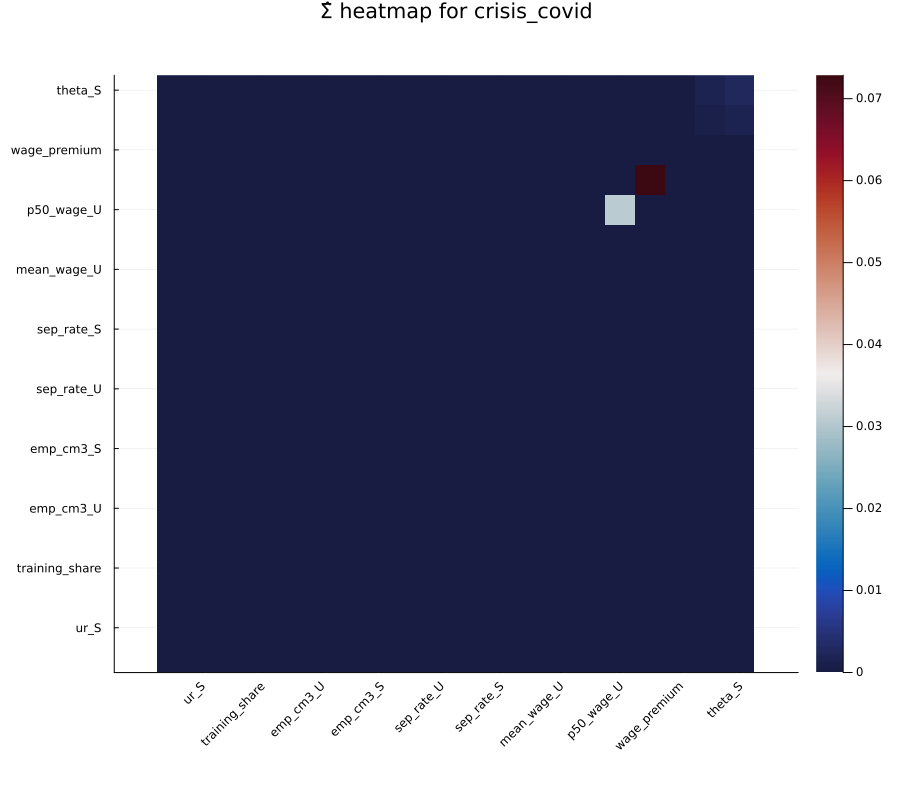

In [27]:
using DataFrames, CSV, LinearAlgebra
using Plots
using StatsPlots

wname = first(keys(all_sigma))   # or pick a specific window symbol
Sigma = all_sigma[wname]

mnames = MOMENT_NAMES
p = heatmap(
    string.(mnames), string.(mnames), Sigma;
    aspect_ratio = 1,
    cmap = :balance,
    colorbar = true,
    title = "Σ̂ heatmap for $(wname)",
    xrotation = 45,
    yrotation = 0,
    size = (900, 800)
)
display(p)

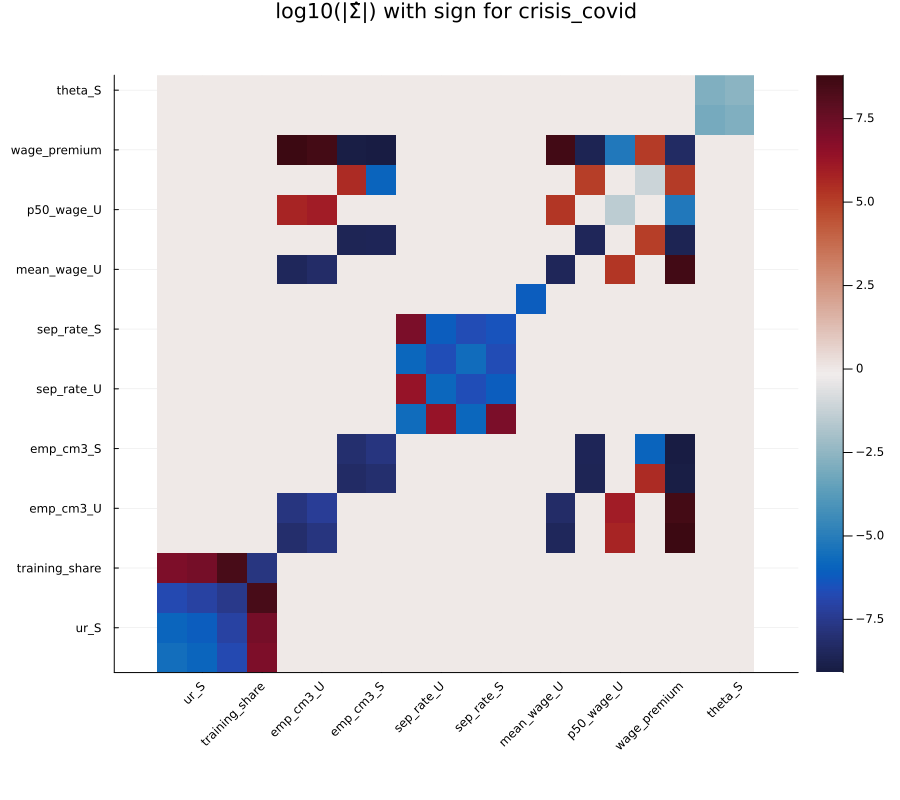

In [28]:
eps0 = 1e-20
Sigma_log = sign.(Sigma) .* log10.(abs.(Sigma) .+ eps0)

p = heatmap(
    string.(MOMENT_NAMES), string.(MOMENT_NAMES), Sigma_log;
    aspect_ratio = 1,
    cmap = :balance,
    colorbar = true,
    title = "log10(|Σ̂|) with sign for $(wname)",
    xrotation = 45,
    yrotation = 0,
    size = (900, 800)
)
display(p)

In [29]:
rank(Sigma), size(Sigma)

(20, (20, 20))

In [30]:
using DataFrames, Statistics

moment_vars = DataFrame(
    moment = String[],
    window = Symbol[],
    variance = Float64[]
)

for (wname, Sigma) in all_sigma
    for (i, m) in enumerate(MOMENT_NAMES)
        push!(moment_vars, (
            String(m),
            wname,
            Sigma[i, i]
        ))
    end
end

var_table = combine(
    groupby(moment_vars, :moment),
    :variance => mean => :mean_variance,
    :variance => minimum => :min_variance,
    :variance => maximum => :max_variance,
    nrow => :n_windows
)

sort!(var_table, :mean_variance, rev=true)
var_table.rank = 1:nrow(var_table)

display(var_table)

# optional save
# CSV.write(joinpath(DERIVED_DIR, "moment_variance_ranking.csv"), var_table)

Row,moment,mean_variance,min_variance,max_variance,n_windows,rank
,String,Float64,Float64,Float64,Int64,Int64
1,p50_wage_S,0.0683486,0.0582578,0.0793419,4,1
2,p50_wage_U,0.0371331,0.0306473,0.0417381,4,2
3,theta_S,0.000735242,0.000167075,0.0023308,4,3
4,theta_U,0.000261796,3.3886e-5,0.000797248,4,4
5,jfr_S,2.32318e-6,1.94108e-6,3.03629e-6,4,5
6,jfr_U,1.18796e-6,7.2138e-7,2.14316e-6,4,6
7,ur_U,7.24472e-7,4.04315e-8,2.52854e-6,4,7
8,sep_rate_U,3.73207e-7,3.06287e-9,1.47508e-6,4,8
9,ee_rate_S,2.52182e-7,2.39812e-8,6.97787e-7,4,9


In [31]:
using DataFrames
using Statistics
using LinearAlgebra

# correlation matrix from Sigma
d = sqrt.(diag(Sigma))
Corr = Sigma ./ (d * d')
Corr[.!isfinite.(Corr)] .= NaN
for i in 1:size(Corr, 1)
    Corr[i, i] = 1.0
end

# collect upper-triangular correlations into a table
pairs = DataFrame(
    moment1 = String[],
    moment2 = String[],
    corr = Float64[],
    abs_corr = Float64[],
)

K = size(Corr, 1)
for i in 1:K-1
    for j in i+1:K
        c = Corr[i, j]
        if isfinite(c)
            push!(pairs, (
                String(MOMENT_NAMES[i]),
                String(MOMENT_NAMES[j]),
                c,
                abs(c)
            ))
        end
    end
end

# rank by absolute correlation
sort!(pairs, :abs_corr, rev=true)
pairs.rank = 1:nrow(pairs)

# show top pairs
display(first(pairs, min(30, nrow(pairs))))

# optional: save to CSV
# CSV.write(joinpath(DERIVED_DIR, "correlation_pairs_ranked.csv"), pairs)

high_corr = filter(row -> row.abs_corr >= 0.9, pairs)
display(high_corr)

Row,moment1,moment2,corr,abs_corr,rank
,String,String,Float64,Float64,Int64
1,theta_U,theta_S,0.986802,0.986802,1
2,sep_rate_U,sep_rate_S,0.984789,0.984789,2
3,ur_U,ur_S,0.974108,0.974108,3
4,emp_var_U,emp_cm3_U,0.92919,0.92919,4
5,emp_var_S,emp_cm3_S,0.861291,0.861291,5
6,mean_wage_U,wage_premium,-0.702155,0.702155,6
7,emp_var_U,mean_wage_U,0.681966,0.681966,7
8,jfr_U,jfr_S,0.656351,0.656351,8
9,mean_wage_S,p50_wage_S,-0.622344,0.622344,9


Row,moment1,moment2,corr,abs_corr,rank
,String,String,Float64,Float64,Int64
1,theta_U,theta_S,0.986802,0.986802,1
2,sep_rate_U,sep_rate_S,0.984789,0.984789,2
3,ur_U,ur_S,0.974108,0.974108,3
4,emp_var_U,emp_cm3_U,0.92919,0.92919,4


In [32]:
# eigenvalues of sigma
sigma_eigvals = eigen(Sigma)

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
20-element Vector{Float64}:
 5.842393219607772e-11
 3.465326158496585e-10
 7.627862790871392e-10
 1.5414627578617374e-9
 2.6260741134846974e-9
 3.3807554128790657e-9
 8.908288505632836e-9
 1.739970353527613e-8
 2.0454052834661428e-8
 3.2591804780685606e-8
 5.0464830701455023e-8
 5.503902584246549e-7
 6.977874712002923e-7
 1.9833991781760093e-6
 3.196959451469437e-6
 3.5866479649065294e-6
 1.5655901914903708e-5
 0.0031123963037173923
 0.030647302327920182
 0.0728648032857317
vectors:
20×20 Matrix{Float64}:
  0.0           0.0           0.0          …   0.0           0.0
  0.0           0.0           0.0              0.0           0.0
  0.0           0.0           0.0              0.0           0.0
  0.0           0.0           0.0              0.0           0.0
  0.368961      0.542172      0.558677         5.49551e-5   -2.39165e-12
 -0.0777783    -0.1564       -0.214004     …   3.14449e-5   -3.5005e-12
 -0.209648      0.

---
## Stage 9 — Validation and Diagnostics

Spot-check moments against published benchmarks. Cross-window comparison.
Tightness level check. EE rate validation. Training share check.

In [33]:
function run_validation(all_moments, all_sigma)
    @info "Stage 9: Validation diagnostics..."

    println("\n" * "="^80)
    println("VALIDATION REPORT")
    println("="^80)

    # ── 1. Moment values across windows ───────────────────────────
    println("\n── 1. Moments across windows ──")
    # Build a wide table
    wide = DataFrame(moment = [string(m) for m in MOMENT_NAMES])
    for wname in [:base_fc, :crisis_fc, :base_covid, :crisis_covid]
        haskey(all_moments, wname) || continue
        mdf = all_moments[wname]
        wide[!, string(wname)] = mdf.value
    end
    display(wide)

    # ── 2. Sanity checks with published benchmarks ────────────────
    println("\n── 2. Benchmark comparisons ──")
    benchmarks = Dict(
        :ur_total => (name="Unemployment rate", lo=0.03, hi=0.15,
                      note="BLS: ~5% pre-FC, ~10% peak FC, ~3.5% pre-COVID, ~14% peak COVID"),
        :skilled_share => (name="Skilled share (BA+)", lo=0.20, hi=0.50,
                           note="CPS: ~30% in 2003, rising to ~40% by 2020"),
        :training_share => (name="Training share", lo=0.005, hi=0.05,
                            note="~2% of LF enrolled part-time in college w/o BA"),
        :theta_U => (name="Unskilled tightness V/U", lo=0.1, hi=5.0,
                     note="JOLTS/CPS: ~0.5-1.0 pre-crisis, lower in crisis"),
        :theta_S => (name="Skilled tightness V/U", lo=0.1, hi=10.0,
                     note="Typically higher than unskilled"),
        :jfr_U => (name="Unskilled JF rate (monthly)", lo=0.10, hi=0.50,
                   note="Shimer (2005): ~0.45 average, lower in recessions"),
        :sep_rate_U => (name="Unskilled EU sep rate (monthly)", lo=0.005, hi=0.05,
                        note="Shimer (2005): ~0.03 average, higher in recessions"),
        :ee_rate_S => (name="Skilled EE rate (monthly)", lo=0.005, hi=0.05,
                       note="J2J: quarterly ~2-4%, monthly ~0.7-1.5%"),
        :wage_premium => (name="Log skill premium", lo=0.20, hi=0.80,
                          note="~0.40-0.60 typical"),
    )

    n_flags = 0
    for (mname, bm) in benchmarks
        for wname in [:base_fc, :crisis_fc, :base_covid, :crisis_covid]
            haskey(all_moments, wname) || continue
            mdf = all_moments[wname]
            row = filter(r -> r.moment == string(mname), mdf)
            isempty(row) && continue
            val = row.value[1]
            !isfinite(val) && continue
            flag = val < bm.lo || val > bm.hi ? "⚠ OUT OF RANGE" : "✓"
            if flag != "✓"
                @printf("  %s  %-25s %12s = %8.4f  (expected %.3f–%.3f)\n",
                        flag, bm.name, wname, val, bm.lo, bm.hi)
                n_flags += 1
            end
        end
    end
    println("  Flagged: $n_flags values outside expected ranges")

    # ── 3. Cross-window direction checks ──────────────────────────
    println("\n── 3. Cross-window direction checks ──")
    # During crises, unemployment should rise, JFR should fall, sep should rise
    expected_directions = [
        (:ur_total, :base_fc, :crisis_fc, +1, "UR should rise in FC"),
        (:ur_total, :base_covid, :crisis_covid, +1, "UR should rise in COVID"),
        (:jfr_U, :base_fc, :crisis_fc, -1, "JFR should fall in FC"),
        (:theta_U, :base_fc, :crisis_fc, -1, "Tightness should fall in FC"),
        (:theta_U, :base_covid, :crisis_covid, -1, "Tightness should fall in COVID"),
    ]
    for (mname, w1, w2, expected_sign, desc) in expected_directions
        haskey(all_moments, w1) && haskey(all_moments, w2) || continue
        v1 = filter(r -> r.moment == string(mname), all_moments[w1]).value[1]
        v2 = filter(r -> r.moment == string(mname), all_moments[w2]).value[1]
        (!isfinite(v1) || !isfinite(v2)) && continue
        actual_sign = sign(v2 - v1)
        flag = actual_sign == expected_sign ? "✓" : "⚠ UNEXPECTED"
        @printf("  %s  %s: %.4f → %.4f (Δ=%.4f)\n", flag, desc, v1, v2, v2-v1)
    end

    # ── 4. Σ̂ diagnostics ─────────────────────────────────────────
    println("\n── 4. Σ̂ condition numbers ──")
    for wname in [:base_fc, :crisis_fc, :base_covid, :crisis_covid]
        haskey(all_sigma, wname) || continue
        Sig = all_sigma[wname]
        d = diag(Sig)
        n_zero = count(d .<= 0)
        cn = cond(Sig)
        @printf("  %s: κ = %.2e, zero-diagonal = %d\n", wname, cn, n_zero)
    end

    println("\n" * "="^80)
    println("END VALIDATION REPORT")
    println("="^80)
end

run_validation(all_moments, all_sigma)


VALIDATION REPORT

── 1. Moments across windows ──


┌ Info: Stage 9: Validation diagnostics...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y103sZmlsZQ==.jl:2


ArgumentError: ArgumentError: column name :value not found in the data frame

---
## Pipeline Summary

List all derived files produced by the pipeline.

In [34]:
println("Derived files in: $DERIVED_DIR")
for f in sort(readdir(DERIVED_DIR))
    sz = filesize(joinpath(DERIVED_DIR, f))
    @printf("  %-40s  %s\n", f, Base.format_bytes(sz))
end

println("\nKey outputs:")
println("  • moments_{window}.csv    — 24 moments per window")
println("  • sigma_{window}.csv      — 24×24 variance-covariance matrix")
println("  • W_{window}.csv          — SMM weight matrix")
println("  • j2j_ee_rates.csv        — J2J EE rates by skill and window")
println("  • nu_estimate.csv         — demographic turnover rate ν")
println("  • phi_calibration.csv     — training completion rate φ")

Derived files in: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived
  W_base_covid.csv                          2.859 KiB
  W_base_fc.csv                             2.856 KiB
  W_crisis_covid.csv                        2.850 KiB
  W_crisis_fc.csv                           2.853 KiB
  W_reduced_base_covid.csv                  2.066 KiB
  W_reduced_base_fc.csv                     2.066 KiB
  W_reduced_crisis_covid.csv                2.063 KiB
  W_reduced_crisis_fc.csv                   2.063 KiB
  cps_asec_clean.arrow                      16.636 MiB
  cps_basic_clean.arrow                     2.938 GiB
  economy_skill_shares.arrow                1.018 KiB
  industry_skill_shares.arrow               3.713 KiB
  j2j_ee_rates.csv                          235 bytes
  jolts_clean.arrow                         12.494 KiB
  moments_base_covid.csv                    725 bytes
  moments_base_fc.csv                       723 bytes
  moments_cris